---
title: "Project"
author: Jordan Alfano and Matthew Hoch
date: 2025-05-14

toc: true
---

# Packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate # for table summary
import scipy.stats as stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # for lowess smoothing
import xgboost as xgb

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import r2_score
from sklearn.preprocessing import scale # zero mean & one s.d.
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, calinski_harabasz_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from pyspark.sql import SparkSession
from pyspark.sql.functions import rand, col, pow, mean, avg, when, log, sqrt, exp
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, GeneralizedLinearRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

spark = SparkSession.builder.master("local[*]").getOrCreate()

from xgboost import XGBRegressor, plot_importance

# UDFs

## Linear Regression

### regression table

In [ ]:
def regression_table(model, assembler):
    """
    Creates a formatted regression table from a fitted LinearRegression model and its VectorAssembler.

    If the model’s labelCol (retrieved using getLabelCol()) starts with "log", an extra column showing np.exp(coeff)
    is added immediately after the beta estimate column for predictor rows. Additionally, np.exp() of the 95% CI
    Lower and Upper bounds is also added unless the predictor's name includes "log_". The Intercept row does not
    include exponentiated values.

    When labelCol starts with "log", the columns are ordered as:
        y: [label] | Beta | Exp(Beta) | Sig. | Std. Error | p-value | 95% CI Lower | Exp(95% CI Lower) | 95% CI Upper | Exp(95% CI Upper)

    Otherwise, the columns are:
        y: [label] | Beta | Sig. | Std. Error | p-value | 95% CI Lower | 95% CI Upper

    Parameters:
        model: A fitted LinearRegression model (with a .summary attribute and a labelCol).
        assembler: The VectorAssembler used to assemble the features for the model.

    Returns:
        A formatted string containing the regression table.
    """
    # Determine if we should display exponential values for coefficients.
    is_log = model.getLabelCol().lower().startswith("log")

    # Extract coefficients and standard errors as NumPy arrays.
    coeffs = model.coefficients.toArray()
    std_errors_all = np.array(model.summary.coefficientStandardErrors)

    # Check if the intercept's standard error is included (one extra element).
    if len(std_errors_all) == len(coeffs) + 1:
        intercept_se = std_errors_all[0]
        std_errors = std_errors_all[1:]
    else:
        intercept_se = None
        std_errors = std_errors_all

    # Use provided tValues and pValues.
    df = model.summary.numInstances - len(coeffs) - 1
    t_critical = stats.t.ppf(0.975, df)
    p_values = model.summary.pValues

    # Helper: significance stars.
    def significance_stars(p):
        if p < 0.01:
            return "***"
        elif p < 0.05:
            return "**"
        elif p < 0.1:
            return "*"
        else:
            return ""

    # Build table rows for each feature.
    table = []
    for feature, beta, se, p in zip(assembler.getInputCols(), coeffs, std_errors, p_values):
        ci_lower = beta - t_critical * se
        ci_upper = beta + t_critical * se

        # Check if predictor contains "log_" to determine if exponentiation should be applied
        apply_exp = is_log and "log_" not in feature.lower()

        exp_beta = np.exp(beta) if apply_exp else ""
        exp_ci_lower = np.exp(ci_lower) if apply_exp else ""
        exp_ci_upper = np.exp(ci_upper) if apply_exp else ""

        if is_log:
            table.append([
                feature,            # Predictor name
                beta,               # Beta estimate
                exp_beta,           # Exponential of beta (or blank)
                significance_stars(p),
                se,
                p,
                ci_lower,
                exp_ci_lower,       # Exponential of 95% CI lower bound
                ci_upper,
                exp_ci_upper        # Exponential of 95% CI upper bound
            ])
        else:
            table.append([
                feature,
                beta,
                significance_stars(p),
                se,
                p,
                ci_lower,
                ci_upper
            ])

    # Process intercept.
    if intercept_se is not None:
        intercept_p = model.summary.pValues[0] if model.summary.pValues is not None else None
        intercept_sig = significance_stars(intercept_p)
        ci_intercept_lower = model.intercept - t_critical * intercept_se
        ci_intercept_upper = model.intercept + t_critical * intercept_se
    else:
        intercept_sig = ""
        ci_intercept_lower = ""
        ci_intercept_upper = ""
        intercept_se = ""

    if is_log:
        table.append([
            "Intercept",
            model.intercept,
            "",                    # Removed np.exp(model.intercept)
            intercept_sig,
            intercept_se,
            "",
            ci_intercept_lower,
            "",
            ci_intercept_upper,
            ""
        ])
    else:
        table.append([
            "Intercept",
            model.intercept,
            intercept_sig,
            intercept_se,
            "",
            ci_intercept_lower,
            ci_intercept_upper
        ])

    # Append overall model metrics.
    if is_log:
        table.append(["Observations", model.summary.numInstances, "", "", "", "", "", "", "", ""])
        table.append(["R²", model.summary.r2, "", "", "", "", "", "", "", ""])
        table.append(["RMSE", model.summary.rootMeanSquaredError, "", "", "", "", "", "", "", ""])
    else:
        table.append(["Observations", model.summary.numInstances, "", "", "", "", ""])
        table.append(["R²", model.summary.r2, "", "", "", "", ""])
        table.append(["RMSE", model.summary.rootMeanSquaredError, "", "", "", "", ""])

    # Format the table rows.
    formatted_table = []
    for row in table:
        formatted_row = []
        for i, item in enumerate(row):
            # Format Observations as integer with commas.
            if row[0] == "Observations" and i == 1 and isinstance(item, (int, float, np.floating)) and item != "":
                formatted_row.append(f"{int(item):,}")
            elif isinstance(item, (int, float, np.floating)) and item != "":
                if is_log:
                    # When is_log, the columns are:
                    # 0: Metric, 1: Beta, 2: Exp(Beta), 3: Sig, 4: Std. Error, 5: p-value,
                    # 6: 95% CI Lower, 7: Exp(95% CI Lower), 8: 95% CI Upper, 9: Exp(95% CI Upper).
                    if i in [1, 2, 4, 6, 7, 8, 9]:
                        formatted_row.append(f"{item:,.3f}")
                    elif i == 5:
                        formatted_row.append(f"{item:.3f}")
                    else:
                        formatted_row.append(f"{item:.3f}")
                else:
                    # When not is_log, the columns are:
                    # 0: Metric, 1: Beta, 2: Sig, 3: Std. Error, 4: p-value, 5: 95% CI Lower, 6: 95% CI Upper.
                    if i in [1, 3, 5, 6]:
                        formatted_row.append(f"{item:,.3f}")
                    elif i == 4:
                        formatted_row.append(f"{item:.3f}")
                    else:
                        formatted_row.append(f"{item:.3f}")
            else:
                formatted_row.append(item)
        formatted_table.append(formatted_row)

    # Set header and column alignment based on whether label starts with "log"
    if is_log:
        headers = [
            f"y: {model.getLabelCol()}",
            "Beta", "Exp(Beta)", "Sig.", "Std. Error", "p-value",
            "95% CI Lower", "Exp(95% CI Lower)", "95% CI Upper", "Exp(95% CI Upper)"
        ]
        colalign = ("left", "right", "right", "center", "right", "right", "right", "right", "right", "right")
    else:
        headers = [f"y: {model.getLabelCol()}", "Beta", "Sig.", "Std. Error", "p-value", "95% CI Lower", "95% CI Upper"]
        colalign = ("left", "right", "center", "right", "right", "right", "right")

    table_str = tabulate(
        formatted_table,
        headers=headers,
        tablefmt="pretty",
        colalign=colalign
    )

    # Insert a dashed line after the Intercept row.
    lines = table_str.split("\n")
    dash_line = '-' * len(lines[0])
    for i, line in enumerate(lines):
        if "Intercept" in line and not line.strip().startswith('+'):
            lines.insert(i+1, dash_line)
            break

    return "\n".join(lines)

# Example usage:
# print(regression_table(model_1, assembler_1))

### add dummy variables

In [ ]:
def add_dummy_variables(var_name, reference_level, category_order=None):
    """
    Creates dummy variables for the specified column in the global DataFrames dtrain and dtest.
    Allows manual setting of category order.

    Parameters:
        var_name (str): The name of the categorical column (e.g., "borough_name").
        reference_level (int): Index of the category to be used as the reference (dummy omitted).
        category_order (list, optional): List of categories in the desired order. If None, categories are sorted.

    Returns:
        dummy_cols (list): List of dummy column names excluding the reference category.
        ref_category (str): The category chosen as the reference.
    """
    global dtrain, dtest

    # Get distinct categories from the training set.
    categories = dtrain.select(var_name).distinct().rdd.flatMap(lambda x: x).collect()

    # Convert booleans to strings if present.
    categories = [str(c) if isinstance(c, bool) else c for c in categories]

    # Use manual category order if provided; otherwise, sort categories.
    if category_order:
        # Ensure all categories are present in the user-defined order
        missing = set(categories) - set(category_order)
        if missing:
            raise ValueError(f"These categories are missing from your custom order: {missing}")
        categories = category_order
    else:
        categories = sorted(categories)

    # Validate reference_level
    if reference_level < 0 or reference_level >= len(categories):
        raise ValueError(f"reference_level must be between 0 and {len(categories) - 1}")

    # Define the reference category
    ref_category = categories[reference_level]
    print("Reference category (dummy omitted):", ref_category)

    # Create dummy variables for all categories
    for cat in categories:
        dummy_col_name = var_name + "_" + str(cat).replace(" ", "_")
        dtrain = dtrain.withColumn(dummy_col_name, when(col(var_name) == cat, 1).otherwise(0))
        dtest = dtest.withColumn(dummy_col_name, when(col(var_name) == cat, 1).otherwise(0))

    # List of dummy columns, excluding the reference category
    dummy_cols = [var_name + "_" + str(cat).replace(" ", "_") for cat in categories if cat != ref_category]

    return dummy_cols, ref_category


# Example usage without category_order:
# dummy_cols_year, ref_category_year = add_dummy_variables('year', 0)

# Example usage with category_order:
# custom_order_wkday = ['sunday', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']
# dummy_cols_wkday, ref_category_wkday = add_dummy_variables('wkday', reference_level=0, category_order = custom_order_wkday)

### residual plot

In [ ]:
def residual_plot(df, label_col, model_name):
    """
    Generates a residual plot for a given test dataframe.

    Parameters:
        df (DataFrame): Spark DataFrame containing the test set with predictions.
        label_col (str): The column name of the actual outcome variable.
        title (str): The title for the residual plot.

    Returns:
        None (displays the plot)
    """
    # Convert to Pandas DataFrame
    df_pd = df.select(["prediction", label_col]).toPandas()
    df_pd["residual"] = df_pd[label_col] - df_pd["prediction"]

    # Scatter plot of residuals vs. predicted values
    plt.scatter(df_pd["prediction"], df_pd["residual"], alpha=0.2, color="darkgray")

    # Use LOWESS smoothing for trend line
    smoothed = sm.nonparametric.lowess(df_pd["residual"], df_pd["prediction"])
    plt.plot(smoothed[:, 0], smoothed[:, 1], color="darkblue")

    # Add reference line at y=0
    plt.axhline(y=0, color="red", linestyle="--")

    # Labels and title (model_name)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    model_name = "Residual Plot for " + model_name
    plt.title(model_name)

    # Show plot
    plt.show()

# Example usage:
# residual_plot(dtest_1, "log_sales", "Model 1")

### add interaction terms

In [ ]:
def add_interaction_terms(var_list1, var_list2, var_list3=None):
    """
    Creates interaction term columns in the global DataFrames dtrain and dtest.

    For two sets of variable names (which may represent categorical (dummy) or continuous variables),
    this function creates two-way interactions by multiplying each variable in var_list1 with each
    variable in var_list2.

    Optionally, if a third list of variable names (var_list3) is provided, the function also creates
    three-way interactions among each variable in var_list1, each variable in var_list2, and each variable
    in var_list3.

    Parameters:
        var_list1 (list): List of column names for the first set of variables.
        var_list2 (list): List of column names for the second set of variables.
        var_list3 (list, optional): List of column names for the third set of variables for three-way interactions.

    Returns:
        A flat list of new interaction column names.
    """
    global dtrain, dtest

    interaction_cols = []

    # Create two-way interactions between var_list1 and var_list2.
    for var1 in var_list1:
        for var2 in var_list2:
            col_name = f"{var1}_*_{var2}"
            dtrain = dtrain.withColumn(col_name, col(var1).cast("double") * col(var2).cast("double"))
            dtest = dtest.withColumn(col_name, col(var1).cast("double") * col(var2).cast("double"))
            interaction_cols.append(col_name)

    # Create two-way interactions between var_list1 and var_list3.
    if var_list3 is not None:
      for var1 in var_list1:
          for var3 in var_list3:
              col_name = f"{var1}_*_{var3}"
              dtrain = dtrain.withColumn(col_name, col(var1).cast("double") * col(var3).cast("double"))
              dtest = dtest.withColumn(col_name, col(var1).cast("double") * col(var3).cast("double"))
              interaction_cols.append(col_name)

    # Create two-way interactions between var_list2 and var_list3.
    if var_list3 is not None:
      for var2 in var_list2:
          for var3 in var_list3:
              col_name = f"{var2}_*_{var3}"
              dtrain = dtrain.withColumn(col_name, col(var2).cast("double") * col(var3).cast("double"))
              dtest = dtest.withColumn(col_name, col(var2).cast("double") * col(var3).cast("double"))
              interaction_cols.append(col_name)

    # If a third list is provided, create three-way interactions.
    if var_list3 is not None:
        for var1 in var_list1:
            for var2 in var_list2:
                for var3 in var_list3:
                    col_name = f"{var1}_*_{var2}_*_{var3}"
                    dtrain = dtrain.withColumn(col_name, col(var1).cast("double") * col(var2).cast("double") * col(var3).cast("double"))
                    dtest = dtest.withColumn(col_name, col(var1).cast("double") * col(var2).cast("double") * col(var3).cast("double"))
                    interaction_cols.append(col_name)

    return interaction_cols

 # Example
 # interaction_cols_brand_price = add_interaction_terms(dummy_cols_brand, ['log_price'])
 # interaction_cols_brand_ad_price = add_interaction_terms(dummy_cols_brand, dummy_cols_ad, ['log_price'])

### compare reg models

In [ ]:
def compare_reg_models(models, assemblers, names=None):
    """
    Produces a single formatted table comparing multiple regression models.

    For each predictor (the union across models, ordered by first appearance), the table shows
    the beta estimate (with significance stars) from each model (blank if not used).
    For a predictor, if a model's outcome (model.getLabelCol()) starts with "log", the cell displays
    both the beta and its exponential (separated by " / "), except when the predictor's name includes "log_".
    (The intercept row does not display exp(.))

    Additional rows for Intercept, Observations, R², and RMSE are appended.

    The header's first column is labeled "Predictor", and subsequent columns are
    "y: [outcome] ([name])" for each model.

    The table is produced in grid format (with vertical lines). A dashed line (using '-' characters)
    is inserted at the top, immediately after the header, and at the bottom.
    Additionally, immediately after the Intercept row, the border line is replaced with one using '='
    (to appear as, for example, "+==============================================+==========================+...").

    Parameters:
        models (list): List of fitted LinearRegression models.
        assemblers (list): List of corresponding VectorAssembler objects.
        names (list, optional): List of model names; defaults to "Model 1", "Model 2", etc.

    Returns:
        A formatted string containing the combined regression table.
    """
    # Default model names.
    if names is None:
        names = [f"Model {i+1}" for i in range(len(models))]

    # For each model, get outcome and determine if that model is log-transformed.
    outcomes = [m.getLabelCol() for m in models]
    is_log_flags = [out.lower().startswith("log") for out in outcomes]

    # Build an ordered union of predictors based on first appearance.
    ordered_predictors = []
    for assembler in assemblers:
        for feat in assembler.getInputCols():
            if feat not in ordered_predictors:
                ordered_predictors.append(feat)

    # Helper for significance stars.
    def significance_stars(p):
        if p is None:
            return ""
        if p < 0.01:
            return "***"
        elif p < 0.05:
            return "**"
        elif p < 0.1:
            return "*"
        else:
            return ""

    # Build rows for each predictor.
    rows = []
    for feat in ordered_predictors:
        row = [feat]
        for m, a, is_log in zip(models, assemblers, is_log_flags):
            feats_model = a.getInputCols()
            if feat in feats_model:
                idx = feats_model.index(feat)
                beta = m.coefficients.toArray()[idx]
                p_val = m.summary.pValues[idx] if m.summary.pValues is not None else None
                stars = significance_stars(p_val)
                cell = f"{beta:.3f}{stars}"
                # Only add exp(beta) if model is log and predictor name does NOT include "log_"
                if is_log and ("log_" not in feat.lower()):
                    cell += f" / {np.exp(beta):,.3f}"
                row.append(cell)
            else:
                row.append("")
        rows.append(row)

    # Build intercept row (do NOT compute exp(intercept)).
    intercept_row = ["Intercept"]
    for m in models:
        std_all = np.array(m.summary.coefficientStandardErrors)
        coeffs = m.coefficients.toArray()
        if len(std_all) == len(coeffs) + 1:
            intercept_p = m.summary.pValues[0] if m.summary.pValues is not None else None
        else:
            intercept_p = None
        sig = significance_stars(intercept_p)
        cell = f"{m.intercept:.3f}{sig}"
        intercept_row.append(cell)
    rows.append(intercept_row)

    # Add Observations row.
    obs_row = ["Observations"]
    for m in models:
        obs = m.summary.numInstances
        obs_row.append(f"{int(obs):,}")
    rows.append(obs_row)

    # Add R² row.
    r2_row = ["R²"]
    for m in models:
        r2_row.append(f"{m.summary.r2:.3f}")
    rows.append(r2_row)

    # Add RMSE row.
    rmse_row = ["RMSE"]
    for m in models:
        rmse_row.append(f"{m.summary.rootMeanSquaredError:.3f}")
    rows.append(rmse_row)

    # Build header: first column "Predictor", then for each model: "y: [outcome] ([name])"
    header = ["Predictor"]
    for out, name in zip(outcomes, names):
        header.append(f"y: {out} ({name})")

    # Create table string using grid format.
    table_str = tabulate(rows, headers=header, tablefmt="grid", colalign=("left",) + ("right",)*len(models))

    # Split into lines.
    lines = table_str.split("\n")

    # Create a dashed line spanning the full width.
    full_width = len(lines[0])
    dash_line = '-' * full_width
    # Create an equals line by replacing '-' with '='.
    eq_line = dash_line.replace('-', '=')

    # Insert a dashed line after the header row.
    lines = table_str.split("\n")
    # In grid format, header and separator are usually the first two lines.
    lines.insert(2, dash_line)

    # Insert an equals line after the Intercept row.
    for i, line in enumerate(lines):
        if line.startswith("|") and "Intercept" in line:
            if i+1 < len(lines):
                lines[i+1] = eq_line
            break

    # Add dashed lines at the very top and bottom.
    final_table = dash_line + "\n" + "\n".join(lines) + "\n" + dash_line

    return final_table

# Example usage:
# print(compare_reg_models([model_1, model_2, model_3],
#                          [assembler_1, assembler_2, assembler_3],
#                          ["Model 1", "Model 2", "Model 3"]))

### compare rsme

In [ ]:
def compare_rmse(test_dfs, label_col, pred_col="prediction", names=None):
    """
    Computes and compares RMSE values for a list of test DataFrames.

    For each DataFrame in test_dfs, this function calculates the RMSE between the actual outcome
    (given by label_col) and the predicted value (given by pred_col, default "prediction"). It then
    produces a formatted table where the first column header is empty and the first row's first cell is
    "RMSE", with each model's RMSE in its own column.

    Parameters:
        test_dfs (list): List of test DataFrames.
        label_col (str): The name of the outcome column.
        pred_col (str, optional): The name of the prediction column (default "prediction").
        names (list, optional): List of model names corresponding to the test DataFrames.
                                Defaults to "Model 1", "Model 2", etc.

    Returns:
        A formatted string containing a table that compares RMSE values for each test DataFrame,
        with one model per column.
    """
    # Set default model names if none provided.
    if names is None:
        names = [f"Model {i+1}" for i in range(len(test_dfs))]

    rmse_values = []
    for df in test_dfs:
        # Create a column for squared error.
        df = df.withColumn("error_sq", pow(col(label_col) - col(pred_col), 2))
        # Calculate RMSE: square root of the mean squared error.
        rmse = df.agg(sqrt(avg("error_sq")).alias("rmse")).collect()[0]["rmse"]
        rmse_values.append(rmse)

    # Build a single row table: first cell "RMSE", then one cell per model with the RMSE value.
    row = ["RMSE"] + [f"{rmse:.3f}" for rmse in rmse_values]

    # Build header: first column header is empty, then model names.
    header = [""] + names

    table_str = tabulate([row], headers=header, tablefmt="grid", colalign=("left",) + ("right",)*len(names))
    return table_str

# Example usage:
# print(compare_rmse([dtest_1, dtest_2, dtest_3], "log_sales", names=["Model 1", "Model 2", "Model 3"]))

## Logistic Regression

### marginal effects

In [ ]:
def marginal_effects(model, means):
    """
    Compute marginal effects for all predictors in a PySpark GeneralizedLinearRegression model (logit)
    and return a formatted table with statistical significance and standard errors.

    Parameters:
        model: Fitted GeneralizedLinearRegression model (with binomial family and logit link).
        means: List of mean values for the predictor variables.

    Returns:
        - A formatted string containing the marginal effects table.
        - A Pandas DataFrame with marginal effects, standard errors, confidence intervals, and significance stars.
    """
    global assembler_predictors  # Use the global assembler_predictors list

    # Extract model coefficients, standard errors, and intercept
    coeffs = np.array(model.coefficients)
    std_errors = np.array(model.summary.coefficientStandardErrors)
    intercept = model.intercept

    # Compute linear combination of means and coefficients (XB)
    XB = np.dot(means, coeffs) + intercept

    # Compute derivative of logistic function (G'(XB))
    G_prime_XB = np.exp(XB) / ((1 + np.exp(XB)) ** 2)

    # Helper: significance stars.
    def significance_stars(p):
        if p < 0.01:
            return "***"
        elif p < 0.05:
            return "**"
        elif p < 0.1:
            return "*"
        else:
            return ""

    # Create lists to store results
    results = []
    df_results = []  # For Pandas DataFrame

    for i, predictor in enumerate(assembler_predictors):
        # Compute marginal effect
        marginal_effect = G_prime_XB * coeffs[i]

        # Compute standard error of the marginal effect
        std_error = G_prime_XB * std_errors[i]

        # Compute z-score and p-value
        z_score = marginal_effect / std_error if std_error != 0 else np.nan
        p_value = 2 * (1 - norm.cdf(abs(z_score))) if not np.isnan(z_score) else np.nan

        # Compute confidence interval (95%)
        ci_lower = marginal_effect - 1.96 * std_error
        ci_upper = marginal_effect + 1.96 * std_error

        # Append results for table formatting
        results.append([
            predictor,
            f"{marginal_effect: .6f}",
            significance_stars(p_value),
            f"{std_error: .6f}",
            f"{ci_lower: .6f}",
            f"{ci_upper: .6f}"
        ])

        # Append results for Pandas DataFrame
        df_results.append({
            "Variable": predictor,
            "Marginal Effect": marginal_effect,
            "Significance": significance_stars(p_value),
            "Std. Error": std_error,
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper
        })

    # Convert results to formatted table
    table_str = tabulate(results, headers=["Variable", "Marginal Effect", "Significance", "Std. Error", "95% CI Lower", "95% CI Upper"],
                         tablefmt="pretty", colalign=("left", "decimal", "left", "decimal", "decimal", "decimal"))

    # Convert results to Pandas DataFrame
    df_results = pd.DataFrame(df_results)

    return table_str, df_results

# Example usage:
# means = [0.5, 30]  # Mean values for x1 and x2
# assembler_predictors = ['x1', 'x2']  # Define globally before calling the function
# table_output, df_output = marginal_effects(fitted_model, means)
# print(table_output)
# display(df_output)

# Load Data

Topic: For our project, we chose to explore how U.S. inflation rates from 2000 to 2023 have affected healthcare spending. This topic is especially important because inflation directly impacts the cost of medical services, insurance premiums, prescription drugs, and out-of-pocket expenses for individuals and families. As inflation rises, it can place additional financial strain on households and influence how healthcare is accessed and delivered. By analyzing the relationship between inflation trends and healthcare expenditures over this 23-year span, we aim to uncover patterns, assess policy impacts, and better understand the challenges inflation poses to one of the country’s most critical sectors.



Statement of Purpose: This project argues that inflation has had a significant and measurable impact on healthcare spending in the United States from 2000 to 2023, affecting both individual affordability and national healthcare expenditures. By analyzing economic data over this 23-year span, we aim to identify patterns and evaluate how inflation has shaped healthcare access, cost, and policy.


Data Story Telling:

Questions: How have inflation trends fluctuated over time, and what factors might explain the spikes in specific years like 2002 and 2016?
How has inflation impacted the affordability of prescription drugs for the average consumer over time?
How do policy changes, government funding, or industry dynamics affect home health costs during periods of inflation?
How does inflation affect consumer demand or insurance coverage for non-durable medical products?
How does consumer demand or out-of-pocket payment structure affect the stability of dental care prices amid inflation?
Does expanded insurance access lead to more efficient use of resources, ultimately reducing total healthcare expenditures?
Is the growth in hospital costs more linear or exponential, and what does that imply for future spending?



Data Transformation: All the data used in the study was gathered from the National Health Spending Explorer, which tracks healthcare costs, in billions of dollars (USD) .
The data is not formatted numerically, so any variables we study here had to be properly converted for usage with regression analysis and other models.


Data Visualization:

In [ ]:
# Matthew's chunk
health = pd.read_csv('/content/drive/MyDrive/Data_Analytics/320/healthcare_spending.csv')
health = health.dropna()
health

,Year,Average Inflation Rate,Non-Durable Medical Products,Hospitals,Physicians & Clinics,Dental,Other Professional Services,Retail Prescription Drugs,Home Health,Nursing Care,...,Nursing Care Pct Change,Other Health and Residential Pct Change,Health Consumption Pct Change,Personal Health Care Pct Change,Durable Medical Equipment Pct Change,State and Local Administration Pct Change,Total Administration Pct Change,Federal Administration Pct Change,Net Cost of Health Insurance Pct Change,Total National Health Expenditures Pct Change
0,2000,2.9,$1.43,$355.56,$216.79,$32.91,$19.32,$83.37,$23.23,$51.90,...,5.78%,5.12%,5.99%,5.55%,12.68%,7.73%,11.51%,13.99%,11.34%,4.64%
1,2001,4.1,$1.58,$387.83,$237.77,$36.75,$21.98,$98.23,$25.06,$57.45,...,8.51%,8.24%,8.24%,8.27%,6.05%,12.35%,7.83%,4.29%,8.17%,6.46%
2,2002,8.0,$1.68,$421.26,$259.84,$39.81,$23.92,$109.17,$27.68,$60.68,...,4.26%,10.35%,8.84%,7.79%,19.95%,6.02%,21.49%,12.09%,24.83%,8.52%
3,2003,4.7,$1.86,$453.42,$281.52,$41.08,$26.25,$123.78,$31.44,$63.40,...,2.32%,6.08%,6.66%,6.07%,2.96%,6.75%,13.07%,6.39%,14.78%,6.31%
4,2004,1.2,$2.03,$489.33,$297.83,$44.62,$28.91,$137.10,$35.64,$67.25,...,3.50%,7.10%,5.09%,5.26%,2.70%,-0.06%,3.32%,7.71%,2.82%,4.43%
5,2005,1.8,$2.14,$528.13,$318.50,$47.40,$30.90,$146.55,$39.97,$71.61,...,3.50%,3.87%,4.45%,4.48%,7.38%,3.72%,4.21%,3.88%,4.30%,3.97%
6,2006,2.4,$2.30,$563.33,$337.57,$48.27,$32.61,$165.41,$43.72,$74.57,...,1.29%,4.18%,4.43%,4.11%,9.34%,10.08%,7.66%,-0.04%,8.84%,3.91%
7,2007,2.1,$2.54,$596.90,$356.71,$51.67,$35.44,$176.66,$49.27,$79.06,...,3.37%,4.75%,3.78%,3.72%,2.52%,-3.56%,4.33%,3.83%,4.98%,3.82%
8,2008,1.3,$2.72,$629.74,$377.30,$53.79,$38.56,$184.36,$53.91,$84.48,...,3.78%,1.89%,2.12%,2.58%,0.54%,2.26%,-2.48%,0.05%,-3.19%,1.21%
9,2009,0.1,$2.79,$670.91,$395.79,$56.27,$40.86,$196.82,$59.13,$89.31,...,6.01%,9.90%,6.03%,6.50%,0.75%,3.26%,1.11%,3.90%,0.50%,4.05%


In [ ]:
# Jordan's chunk
health = pd.read_csv("/content/drive/MyDrive/NYS_SVI_data/healthcare_spending.csv")
health

,Year,Average Inflation Rate,Non-Durable Medical Products,Hospitals,Physicians & Clinics,Dental,Other Professional Services,Retail Prescription Drugs,Home Health,Nursing Care,...,Nursing Care Pct Change,Other Health and Residential Pct Change,Health Consumption Pct Change,Personal Health Care Pct Change,Durable Medical Equipment Pct Change,State and Local Administration Pct Change,Total Administration Pct Change,Federal Administration Pct Change,Net Cost of Health Insurance Pct Change,Total National Health Expenditures Pct Change
0,2000,2.9,$1.43,$355.56,$216.79,$32.91,$19.32,$83.37,$23.23,$51.90,...,5.78%,5.12%,5.99%,5.55%,12.68%,7.73%,11.51%,13.99%,11.34%,4.64%
1,2001,4.1,$1.58,$387.83,$237.77,$36.75,$21.98,$98.23,$25.06,$57.45,...,8.51%,8.24%,8.24%,8.27%,6.05%,12.35%,7.83%,4.29%,8.17%,6.46%
2,2002,8.0,$1.68,$421.26,$259.84,$39.81,$23.92,$109.17,$27.68,$60.68,...,4.26%,10.35%,8.84%,7.79%,19.95%,6.02%,21.49%,12.09%,24.83%,8.52%
3,2003,4.7,$1.86,$453.42,$281.52,$41.08,$26.25,$123.78,$31.44,$63.40,...,2.32%,6.08%,6.66%,6.07%,2.96%,6.75%,13.07%,6.39%,14.78%,6.31%
4,2004,1.2,$2.03,$489.33,$297.83,$44.62,$28.91,$137.10,$35.64,$67.25,...,3.50%,7.10%,5.09%,5.26%,2.70%,-0.06%,3.32%,7.71%,2.82%,4.43%
5,2005,1.8,$2.14,$528.13,$318.50,$47.40,$30.90,$146.55,$39.97,$71.61,...,3.50%,3.87%,4.45%,4.48%,7.38%,3.72%,4.21%,3.88%,4.30%,3.97%
6,2006,2.4,$2.30,$563.33,$337.57,$48.27,$32.61,$165.41,$43.72,$74.57,...,1.29%,4.18%,4.43%,4.11%,9.34%,10.08%,7.66%,-0.04%,8.84%,3.91%
7,2007,2.1,$2.54,$596.90,$356.71,$51.67,$35.44,$176.66,$49.27,$79.06,...,3.37%,4.75%,3.78%,3.72%,2.52%,-3.56%,4.33%,3.83%,4.98%,3.82%
8,2008,1.3,$2.72,$629.74,$377.30,$53.79,$38.56,$184.36,$53.91,$84.48,...,3.78%,1.89%,2.12%,2.58%,0.54%,2.26%,-2.48%,0.05%,-3.19%,1.21%
9,2009,0.1,$2.79,$670.91,$395.79,$56.27,$40.86,$196.82,$59.13,$89.31,...,6.01%,9.90%,6.03%,6.50%,0.75%,3.26%,1.11%,3.90%,0.50%,4.05%


In [ ]:
health.columns

Index(['Year', 'Average Inflation Rate', 'Non-Durable Medical Products',
       'Hospitals', 'Physicians & Clinics', 'Dental',
       'Other Professional Services', 'Retail Prescription Drugs',
       'Home Health', 'Nursing Care', 'Other Health and Residential',
       'Health Consumption', 'Personal Health Care',
       'Durable Medical Equipment', 'State and Local Administration',
       'Total Administration', 'Federal Administration',
       'Net Cost of Health Insurance', 'Total National Health Expenditures',
       'Non-Durable Medical Products Pct Change', 'Hospitals Pct Change',
       'Physicians & Clinics Pct Change', 'Dental Pct Change',
       'Other Professional Services Pct Change',
       'Retail Prescription Drugs Pct Change', 'Home Health Pct Change',
       'Nursing Care Pct Change', 'Other Health and Residential Pct Change',
       'Health Consumption Pct Change', 'Personal Health Care Pct Change',
       'Durable Medical Equipment Pct Change',
       'State and Loc

In [ ]:
health.columns = ['Year', 'Average_Inflation_Rate', 'Non-Durable_Medical_Products',
 'Hospitals', 'Physicians_and_Clinics', 'Dental',
 'Other_Professional_Services', 'Retail_Prescription_Drugs',
 'Home_Health', 'Nursing_Care', 'Other_Health_and_Residential',
 'Health_Consumption', 'Personal_Health_Care',
 'Durable_Medical_Equipment', 'State_and_Local_Administration',
 'Total_Administration', 'Federal_Administration',
 'Net_Cost_of_Health_Insurance', 'Total_National_Health_Expenditures',
 'Non-Durable_Medical_Products_Pct_Change', 'Hospitals_Pct_Change',
 'Physicians_and_Clinics_Pct_Change', 'Dental_Pct_Change',
 'Other_Professional_Services_Pct_Change',
 'Retail_Prescription_Drugs_Pct_Change', 'Home_Health_Pct_Change',
 'Nursing_Care_Pct_Change', 'Other_Health_and_Residential_Pct_Change',
 'Health_Consumption_Pct_Change', 'Personal_Health_Care_Pct_Change',
 'Durable_Medical_Equipment_Pct_Change',
 'State_and_Local_Administration_Pct_Change',
 'Total_Administration_Pct_Change', 'Federal_Administration_Pct_Change',
 'Net_Cost_of_Health_Insurance_Pct_Change',
 'Total_National_Health_Expenditures_Pct_Change']

In [ ]:
health.columns

Index(['Year', 'Average_Inflation_Rate', 'Non-Durable_Medical_Products',
       'Hospitals', 'Physicians_and_Clinics', 'Dental',
       'Other_Professional_Services', 'Retail_Prescription_Drugs',
       'Home_Health', 'Nursing_Care', 'Other_Health_and_Residential',
       'Health_Consumption', 'Personal_Health_Care',
       'Durable_Medical_Equipment', 'State_and_Local_Administration',
       'Total_Administration', 'Federal_Administration',
       'Net_Cost_of_Health_Insurance', 'Total_National_Health_Expenditures',
       'Non-Durable_Medical_Products_Pct_Change', 'Hospitals_Pct_Change',
       'Physicians_and_Clinics_Pct_Change', 'Dental_Pct_Change',
       'Other_Professional_Services_Pct_Change',
       'Retail_Prescription_Drugs_Pct_Change', 'Home_Health_Pct_Change',
       'Nursing_Care_Pct_Change', 'Other_Health_and_Residential_Pct_Change',
       'Health_Consumption_Pct_Change', 'Personal_Health_Care_Pct_Change',
       'Durable_Medical_Equipment_Pct_Change',
       'State_and

In [ ]:
health.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 23
Data columns (total 36 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Year                                           24 non-null     object 
 1   Average_Inflation_Rate                         24 non-null     float64
 2   Non-Durable_Medical_Products                   24 non-null     object 
 3   Hospitals                                      24 non-null     object 
 4   Physicians_and_Clinics                         24 non-null     object 
 5   Dental                                         24 non-null     object 
 6   Other_Professional_Services                    24 non-null     object 
 7   Retail_Prescription_Drugs                      24 non-null     object 
 8   Home_Health                                    24 non-null     object 
 9   Nursing_Care                                   24 non-null   

In [ ]:
health[['Hospitals', 'Physicians_and_Clinics', 'Dental', 'Retail_Prescription_Drugs']].describe()

,Hospitals,Physicians_and_Clinics,Dental,Retail_Prescription_Drugs
count,24,24,24,24
unique,24,24,24,24
top,$355.56,$216.79,$32.91,$83.37
freq,1,1,1,1


In [ ]:
health['Non-Durable_Medical_Products'] = health['Non-Durable_Medical_Products'].str.replace('$','')
health['Hospitals'] = health['Hospitals'].str.replace('$', '')
health['Physicians_and_Clinics'] = health['Physicians_and_Clinics'].str.replace('$', '')
health['Dental'] = health['Dental'].str.replace('$', '')
health['Other_Professional_Services'] = health['Other_Professional_Services'].str.replace('$','')
health['Retail_Prescription_Drugs'] = health['Retail_Prescription_Drugs'].str.replace('$', '')
health['Home_Health'] = health['Home_Health'].str.replace('$', '')
health['Nursing_Care'] = health['Nursing_Care'].str.replace('$', '')
health['Other_Health_and_Residential'] = health['Other_Health_and_Residential'].str.replace('$', '')
health['Health_Consumption'] = health['Health_Consumption'].str.replace('$', '')
health['Personal_Health_Care'] = health['Personal_Health_Care'].str.replace('$', '')
health['Durable_Medical_Equipment'] = health['Durable_Medical_Equipment'].str.replace('$', '')
health['State_and_Local_Administration'] = health['State_and_Local_Administration'].str.replace('$', '')
health['Total_Administration'] = health['Total_Administration'].str.replace('$', '')
health['Federal_Administration'] = health['Federal_Administration'].str.replace('$', '')
health['Net_Cost_of_Health_Insurance'] = health['Net_Cost_of_Health_Insurance'].str.replace('$', '')
health['Total_National_Health_Expenditures'] = health['Total_National_Health_Expenditures'].str.replace('$', '')

In [ ]:
health['Non-Durable_Medical_Products'].str.replace(',','')
health['Hospitals'] = health['Hospitals'].str.replace(',', '')
health['Physicians_and_Clinics'] = health['Physicians_and_Clinics'].str.replace(',', '')
health['Dental'] = health['Dental'].str.replace(',', '')
health['Other_Professional_Services'].str.replace(',','')
health['Retail_Prescription_Drugs'] = health['Retail_Prescription_Drugs'].str.replace(',', '')
health['Home_Health'] = health['Home_Health'].str.replace(',', '')
health['Nursing_Care'] = health['Nursing_Care'].str.replace(',', '')
health['Other_Health_and_Residential'] = health['Other_Health_and_Residential'].str.replace(',', '')
health['Health_Consumption'] = health['Health_Consumption'].str.replace(',', '')
health['Personal_Health_Care'] = health['Personal_Health_Care'].str.replace(',', '')
health['Durable_Medical_Equipment'] = health['Durable_Medical_Equipment'].str.replace(',', '')
health['State_and_Local_Administration'] = health['State_and_Local_Administration'].str.replace(',', '')
health['Total_Administration'] = health['Total_Administration'].str.replace(',', '')
health['Federal_Administration'] = health['Federal_Administration'].str.replace(',', '')
health['Net_Cost_of_Health_Insurance'] = health['Net_Cost_of_Health_Insurance'].str.replace(',', '')
health['Total_National_Health_Expenditures'] = health['Total_National_Health_Expenditures'].str.replace(',', '')

In [ ]:
health.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 23
Data columns (total 36 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Year                                           24 non-null     object 
 1   Average_Inflation_Rate                         24 non-null     float64
 2   Non-Durable_Medical_Products                   24 non-null     object 
 3   Hospitals                                      24 non-null     object 
 4   Physicians_and_Clinics                         24 non-null     object 
 5   Dental                                         24 non-null     object 
 6   Other_Professional_Services                    24 non-null     object 
 7   Retail_Prescription_Drugs                      24 non-null     object 
 8   Home_Health                                    24 non-null     object 
 9   Nursing_Care                                   24 non-null   

In [ ]:
health = health.dropna()

df = spark.createDataFrame(health)

In [ ]:
health = health.astype({
    'Non-Durable_Medical_Products' : 'float',
    'Hospitals' : 'float',
    'Physicians_and_Clinics' : 'float',
    'Dental' : 'float',
    'Other_Professional_Services' : 'float',
    'Retail_Prescription_Drugs' : 'float',
    'Home_Health' : 'float',
    'Nursing_Care' : 'float',
    'Other_Health_and_Residential' : 'float',
    'Health_Consumption' : 'float',
    'Personal_Health_Care' : 'float',
    'Durable_Medical_Equipment' : 'float',
    'State_and_Local_Administration' : 'float',
    'Total_Administration' : 'float',
    'Federal_Administration' : 'float',
    'Net_Cost_of_Health_Insurance' : 'float',
    'Total_National_Health_Expenditures' : 'float',
    'Year' : 'int64'
})

In [ ]:
health['log_hospitals'] = np.log( health['Hospitals'] )
health['log_physicians'] = np.log( health['Physicians_and_Clinics'] )
health['log_dental'] = np.log( health['Dental'] )
health['log_drugs'] = np.log( health['Retail_Prescription_Drugs'] )

# Descriptive Statistics

In [ ]:
health[['Average_Inflation_Rate','Hospitals','Physicians_and_Clinics','Dental','Non-Durable_Medical_Products',
        'Retail_Prescription_Drugs','Home_Health','Nursing_Care','Health_Consumption','Personal_Health_Care',
        'Durable_Medical_Equipment','Net_Cost_of_Health_Insurance','Total_National_Health_Expenditures']].describe()


,Average_Inflation_Rate,Hospitals,Physicians_and_Clinics,Dental,Non-Durable_Medical_Products,Retail_Prescription_Drugs,Home_Health,Nursing_Care,Health_Consumption,Personal_Health_Care,Durable_Medical_Equipment,Net_Cost_of_Health_Insurance,Total_National_Health_Expenditures
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2.533333,761.144583,457.937083,62.574583,2.509583,215.291250,67.091667,92.844583,2015.682917,1829.022500,22.381250,153.410000,2858.535833
std,1.655995,267.997594,163.501522,18.830021,0.715733,79.443058,29.467828,22.960281,731.046514,654.845623,8.472662,66.193045,985.824178
min,-0.400000,355.560000,216.790000,32.910000,1.430000,83.370000,23.230000,51.900000,902.030000,832.920000,9.820000,53.180000,1366.000000
25%,1.600000,554.530000,332.802500,48.052500,2.082500,160.695000,42.782500,73.830000,1460.550000,1328.127500,17.250000,107.122500,2130.470000
50%,2.350000,738.215000,434.800000,60.940000,2.355000,206.565000,66.560000,98.065000,1936.975000,1765.230000,20.985000,140.205000,2729.905000
75%,3.200000,946.975000,574.402500,74.835000,2.812500,267.025000,87.125000,108.760000,2522.315000,2278.737500,26.152500,198.612500,3485.737500
max,8.000000,1322.830000,808.780000,104.110000,4.680000,386.400000,126.080000,136.280000,3558.620000,3226.840000,42.470000,277.460000,4866.490000


# Data Preparation

In [ ]:
health = health.dropna()

df = spark.createDataFrame(health)


# Data Analysis

## Training / Test Split

In [ ]:
dtrain, dtest = df.randomSplit([0.66, 0.34], seed = 123)

In [ ]:
dtrain.printSchema()

root
 |-- Year: long (nullable = true)
 |-- Average_Inflation_Rate: double (nullable = true)
 |-- Non-Durable_Medical_Products: double (nullable = true)
 |-- Hospitals: double (nullable = true)
 |-- Physicians_and_Clinics: double (nullable = true)
 |-- Dental: double (nullable = true)
 |-- Other_Professional_Services: double (nullable = true)
 |-- Retail_Prescription_Drugs: double (nullable = true)
 |-- Home_Health: double (nullable = true)
 |-- Nursing_Care: double (nullable = true)
 |-- Other_Health_and_Residential: double (nullable = true)
 |-- Health_Consumption: double (nullable = true)
 |-- Personal_Health_Care: double (nullable = true)
 |-- Durable_Medical_Equipment: double (nullable = true)
 |-- State_and_Local_Administration: double (nullable = true)
 |-- Total_Administration: double (nullable = true)
 |-- Federal_Administration: double (nullable = true)
 |-- Net_Cost_of_Health_Insurance: double (nullable = true)
 |-- Total_National_Health_Expenditures: double (nullable = true

## Test Model

In [ ]:
# assembling predictors
conti_cols = ["log_hospitals","log_physicians","log_dental","log_drugs"]

assembler_predictors = (
    conti_cols
)

assembler_1 = VectorAssembler(
    inputCols = assembler_predictors,
    outputCol = "predictors"
)

dtrain_1 = assembler_1.transform(dtrain)
dtest_1  = assembler_1.transform(dtest)

# training model
model_1 = (
    LinearRegression(featuresCol="predictors",
                     labelCol="Average_Inflation_Rate")
    .fit(dtrain_1)
)

# making prediction
dtest_1 = model_1.transform(dtest_1)

# makting regression table
print( regression_table(model_1, assembler_1) )

+---------------------------+---------+------+------------+---------+--------------+--------------+
| y: Average_Inflation_Rate |    Beta | Sig. | Std. Error | p-value | 95% CI Lower | 95% CI Upper |
+---------------------------+---------+------+------------+---------+--------------+--------------+
| log_hospitals             |  -5.029 |      |     18.674 |   0.780 |      -45.082 |       35.023 |
| log_physicians            |  21.578 |      |     18.223 |   0.267 |      -17.506 |       60.663 |
| log_dental                |  -6.047 |      |      6.198 |   0.745 |      -19.340 |        7.247 |
| log_drugs                 | -10.844 |      |     24.048 |   0.102 |      -62.422 |       40.734 |
| Intercept                 | -13.203 |      |     17.624 |         |      -51.002 |       24.596 |
---------------------------------------------------------------------------------------------------
| Observations              |      19 |      |            |         |              |              |


In [ ]:
health

,Year,Average_Inflation_Rate,Non-Durable_Medical_Products,Hospitals,Physicians_and_Clinics,Dental,Other_Professional_Services,Retail_Prescription_Drugs,Home_Health,Nursing_Care,...,Durable_Medical_Equipment_Pct_Change,State_and_Local_Administration_Pct_Change,Total_Administration_Pct_Change,Federal_Administration_Pct_Change,Net_Cost_of_Health_Insurance_Pct_Change,Total_National_Health_Expenditures_Pct_Change,log_hospitals,log_physicians,log_dental,log_drugs
0,2000,2.9,1.43,355.56,216.79,32.91,19.32,83.37,23.23,51.90,...,12.68%,7.73%,11.51%,13.99%,11.34%,4.64%,5.873694,5.378929,3.493777,4.423289
1,2001,4.1,1.58,387.83,237.77,36.75,21.98,98.23,25.06,57.45,...,6.05%,12.35%,7.83%,4.29%,8.17%,6.46%,5.960567,5.471304,3.604138,4.587312
2,2002,8.0,1.68,421.26,259.84,39.81,23.92,109.17,27.68,60.68,...,19.95%,6.02%,21.49%,12.09%,24.83%,8.52%,6.043250,5.560066,3.684118,4.692906
3,2003,4.7,1.86,453.42,281.52,41.08,26.25,123.78,31.44,63.40,...,2.96%,6.75%,13.07%,6.39%,14.78%,6.31%,6.116819,5.640203,3.715521,4.818506
4,2004,1.2,2.03,489.33,297.83,44.62,28.91,137.10,35.64,67.25,...,2.70%,-0.06%,3.32%,7.71%,2.82%,4.43%,6.193037,5.696523,3.798182,4.920711
5,2005,1.8,2.14,528.13,318.50,47.40,30.90,146.55,39.97,71.61,...,7.38%,3.72%,4.21%,3.88%,4.30%,3.97%,6.269342,5.763622,3.858622,4.987367
6,2006,2.4,2.30,563.33,337.57,48.27,32.61,165.41,43.72,74.57,...,9.34%,10.08%,7.66%,-0.04%,8.84%,3.91%,6.333866,5.821773,3.876810,5.108427
7,2007,2.1,2.54,596.90,356.71,51.67,35.44,176.66,49.27,79.06,...,2.52%,-3.56%,4.33%,3.83%,4.98%,3.82%,6.391750,5.876923,3.944877,5.174227
8,2008,1.3,2.72,629.74,377.30,53.79,38.56,184.36,53.91,84.48,...,0.54%,2.26%,-2.48%,0.05%,-3.19%,1.21%,6.445307,5.933041,3.985088,5.216890
9,2009,0.1,2.79,670.91,395.79,56.27,40.86,196.82,59.13,89.31,...,0.75%,3.26%,1.11%,3.90%,0.50%,4.05%,6.508635,5.980884,4.030162,5.282290


Bar Plot

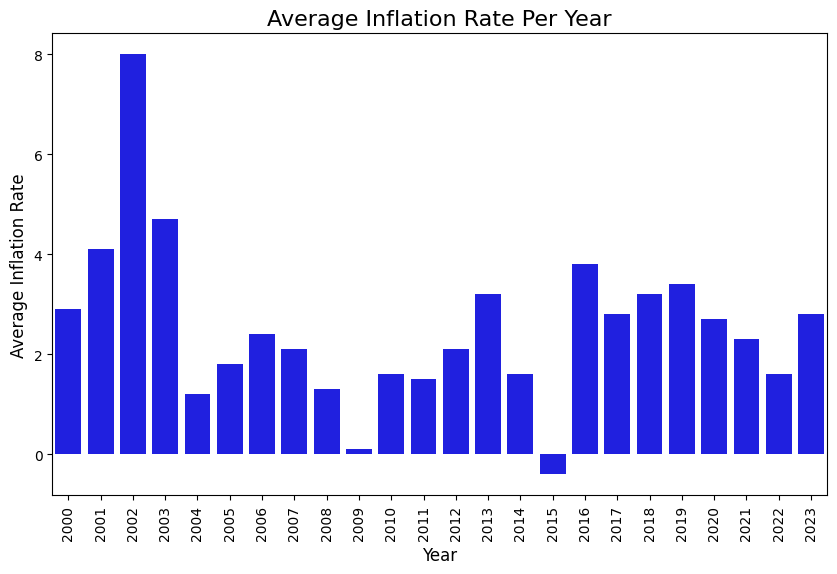

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=health, x='Year', y='Average_Inflation_Rate', color='blue')
plt.title('Average Inflation Rate Per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Average Inflation Rate', fontsize=12)
plt.show()

In [ ]:
print(type(health['Average_Inflation_Rate']))

<class 'pandas.core.series.Series'>


With regards to infation, this graph shows how the average inflation rate has slightly declined overtime from the year 2000-2023. This suggests that prices were rising more slowly in the later years than in the early 2000s. The downward sloping trending line indicated that inflation has decreeased slghtly over the past two decades. Even though the overall trend is downward, there are noticeable spikes and dips in the individual years.

How inflation rate affects Non Durable Medical Products

<Figure size 1000x600 with 0 Axes>

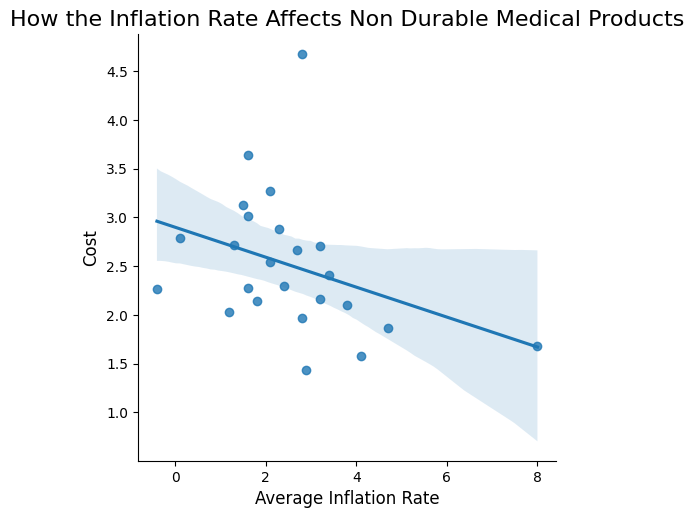

In [ ]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=health, y='Non-Durable_Medical_Products', x='Average_Inflation_Rate')
plt.title('How the Inflation Rate Affects Non Durable Medical Products', fontsize=16)
plt.xlabel('Average Inflation Rate', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.show()

What are they? Nondurable medical products are things such as bandages, gauze, and disposable pads used for managing incontinence. Surgical Supplies: Items like gloves, masks, and sutures are used during surgical procedures. Testing Supplies: Test strips for blood sugar, pregnancy tests, and other diagnostic tools.
There is a clear negative correlation between the average inflation rate and the cost of non-durable medical products — as inflation increases, the cost of these products tends to decrease.
This inverse trend may suggest that non-durable medical products (like bandages, syringes, or disposable supplies) are more likely to experience cost reductions during an inflationary period, potentially due to:


Competitive markets or increased production efficiency


Cost-cutting by healthcare providers or consumers switching to generic/low-cost alternatives


Stronger regulatory pricing controls or bulk procurement strategies

Unlike many healthcare costs that rise with inflation, non-durable medical product costs tend to decline as inflation increases. This may reflect competitive pricing, cost-saving behaviors, or different economic pressures within this sector. It challenges the assumption that inflation uniformly drives up all healthcare-related costs.


How year affects Retail_Prescription_Drugs

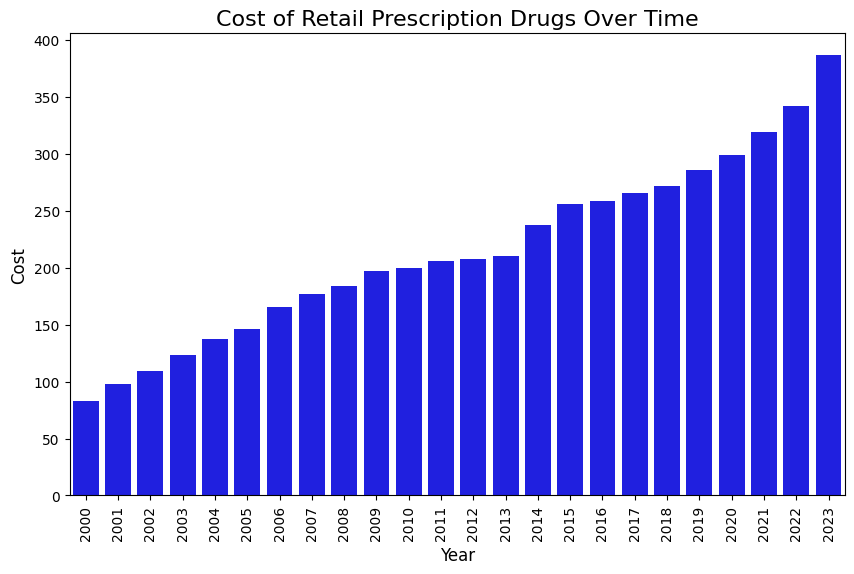

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=health, x='Year', y='Retail_Prescription_Drugs', color='blue')
plt.title('Cost of Retail Prescription Drugs Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel('Cost', fontsize=12)
plt.show()

While inflation rates have fluctuated over the years, rising sharply in some years (like 2002 and 2022) and falling or even going negative in others (like 2015–2016, the cost of retail prescription drugs has increased consistently and steadily from 2000 to 2023.


This suggests that prescription drug prices are not strongly tied to general inflation trends. Instead, their steady rise indicates that other forces—such as industry pricing practices, patent protections, or limited regulation—may be driving costs upward independently of the overall economy.


For example:


In years like 2015, when inflation was negative, drug costs still increased.


During high-inflation years like 2022, drug costs continued their upward trend, but the slope did not drastically steepen, implying that inflation is not the main driver of prescription drug cost increases.


<Figure size 1000x600 with 0 Axes>

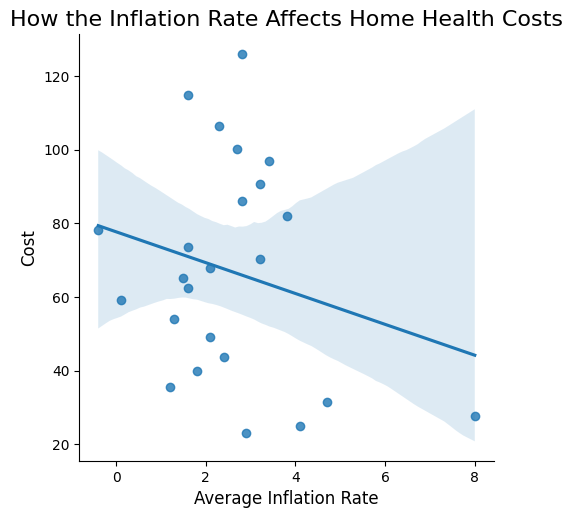

In [ ]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=health, y='Home_Health', x='Average_Inflation_Rate')
plt.title('How the Inflation Rate Affects Home Health Costs', fontsize=16)
plt.xlabel('Average Inflation Rate', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.show()

The average inflation rate has a negative correlation with home health costs, meaning that as inflation increases, home health costs tend to decrease.
This inverse relationship may imply that home health services are more cost-regulated, subsidized, or reduced in demand during high inflation periods.


Alternatively, providers may reduce pricing or limit service availability to stay affordable when economic conditions worsen.


It’s also possible that other economic or policy variables (e.g., Medicare/Medicaid adjustments, labor market changes) play a bigger role in determining home health costs than inflation itself.
Unlike other healthcare sectors (e.g., prescription drugs or hospital bills), home health costs appear to be more inflation-resistant, or even inversely related to inflation. This suggests a unique pricing behavior or market response that deserves further investigation.


Scatter Plot

<Figure size 800x3000 with 0 Axes>

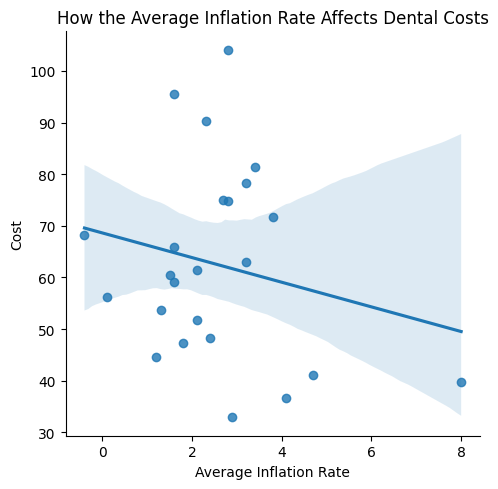

In [ ]:
plt.figure(figsize=(8, 30))
sns.lmplot(data=health, y="Dental", x="Average_Inflation_Rate")

plt.title("How the Average Inflation Rate Affects Dental Costs")
plt.ylabel("Cost")
plt.xlabel("Average Inflation Rate")
plt.tight_layout()
plt.show()


Inflation Rate VS Dental Costs: There is a slight negative correlation between dental care costs and the average inflation rate, meaning that as dental costs increase, the average inflation rate slightly decreases, though the relationship is weak.
This weak relationship may imply that dental pricing is relatively stable, possibly due to:
Out-of-pocket payment structures, where patients bear more direct costs, make providers hesitant to raise prices.


Less government regulation or insurance involvement, which keeps prices detached from inflation-linked reimbursement systems.


The preventive and elective nature of many dental services leads to slower price growth.
While most healthcare sectors experience rising costs tied to inflation, dental costs show minimal correlation, suggesting that this category behaves differently, perhaps due to its unique market structure, consumer behaviors, or payment models. Further study would be needed to confirm why inflation has a limited effect here.



Hospital Bill Costs Per Year

<Figure size 800x3000 with 0 Axes>

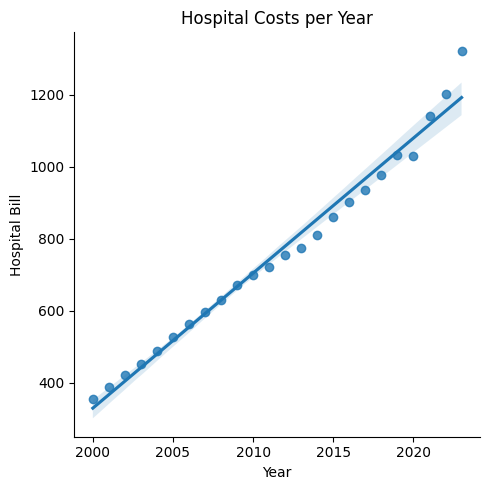

In [ ]:
plt.figure(figsize=(8, 30))
sns.lmplot(data=health, x="Year", y="Hospitals")

plt.title("Hospital Costs per Year")
plt.xlabel("Year")
plt.ylabel("Hospital Bill")
plt.tight_layout()
plt.show()

Hospital Bill costs per year: There is a strong and consistent upward trend in hospital bill costs from 2000 to 2023, indicating that hospital expenses have increased sharply and steadily over time.
The consistent rise likely reflects a combination of:


Technological advancements and new treatments (which can be expensive)


Higher labor and administrative costs


Increased demand for hospital services


Limited price regulation in many areas of U.S. healthcare


This trend may also suggest hospital care is becoming less affordable for many Americans unless offset by insurance or subsidies.
Hospital bills have increased at a rate far above inflation, placing a growing financial burden on patients and the healthcare system. This long-term cost escalation highlights the need for cost containment strategies, policy reform, and improved pricing transparency in hospital care.



Lasso Linear Regression

In [ ]:
dtrain_pd = dtrain.toPandas()
dtest_pd = dtest.toPandas()

X_train = dtrain_pd[conti_cols]
X_test = dtest_pd[conti_cols]
y_train = dtrain_pd['Average_Inflation_Rate']
y_test = dtest_pd['Average_Inflation_Rate']

In [ ]:
lasso_model = LassoCV(cv=5, random_state=42).fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.016313363651590862, tolerance: 0.0023137333333333337
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.022296429889799185, tolerance: 0.0023137333333333337
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.022783027138238765, tolerance: 0.0023137333333333337
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.p

In [ ]:
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
y_pred
mse

5.3477589056224595

In [ ]:
print("Lasso Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Lasso Regression Model Evaluation:
Mean Squared Error (MSE): 5.35
R² Score: 0.25


Regression Tree and Prunned Regression tree

Training MSE: 0.006
Test MSE: 4.040


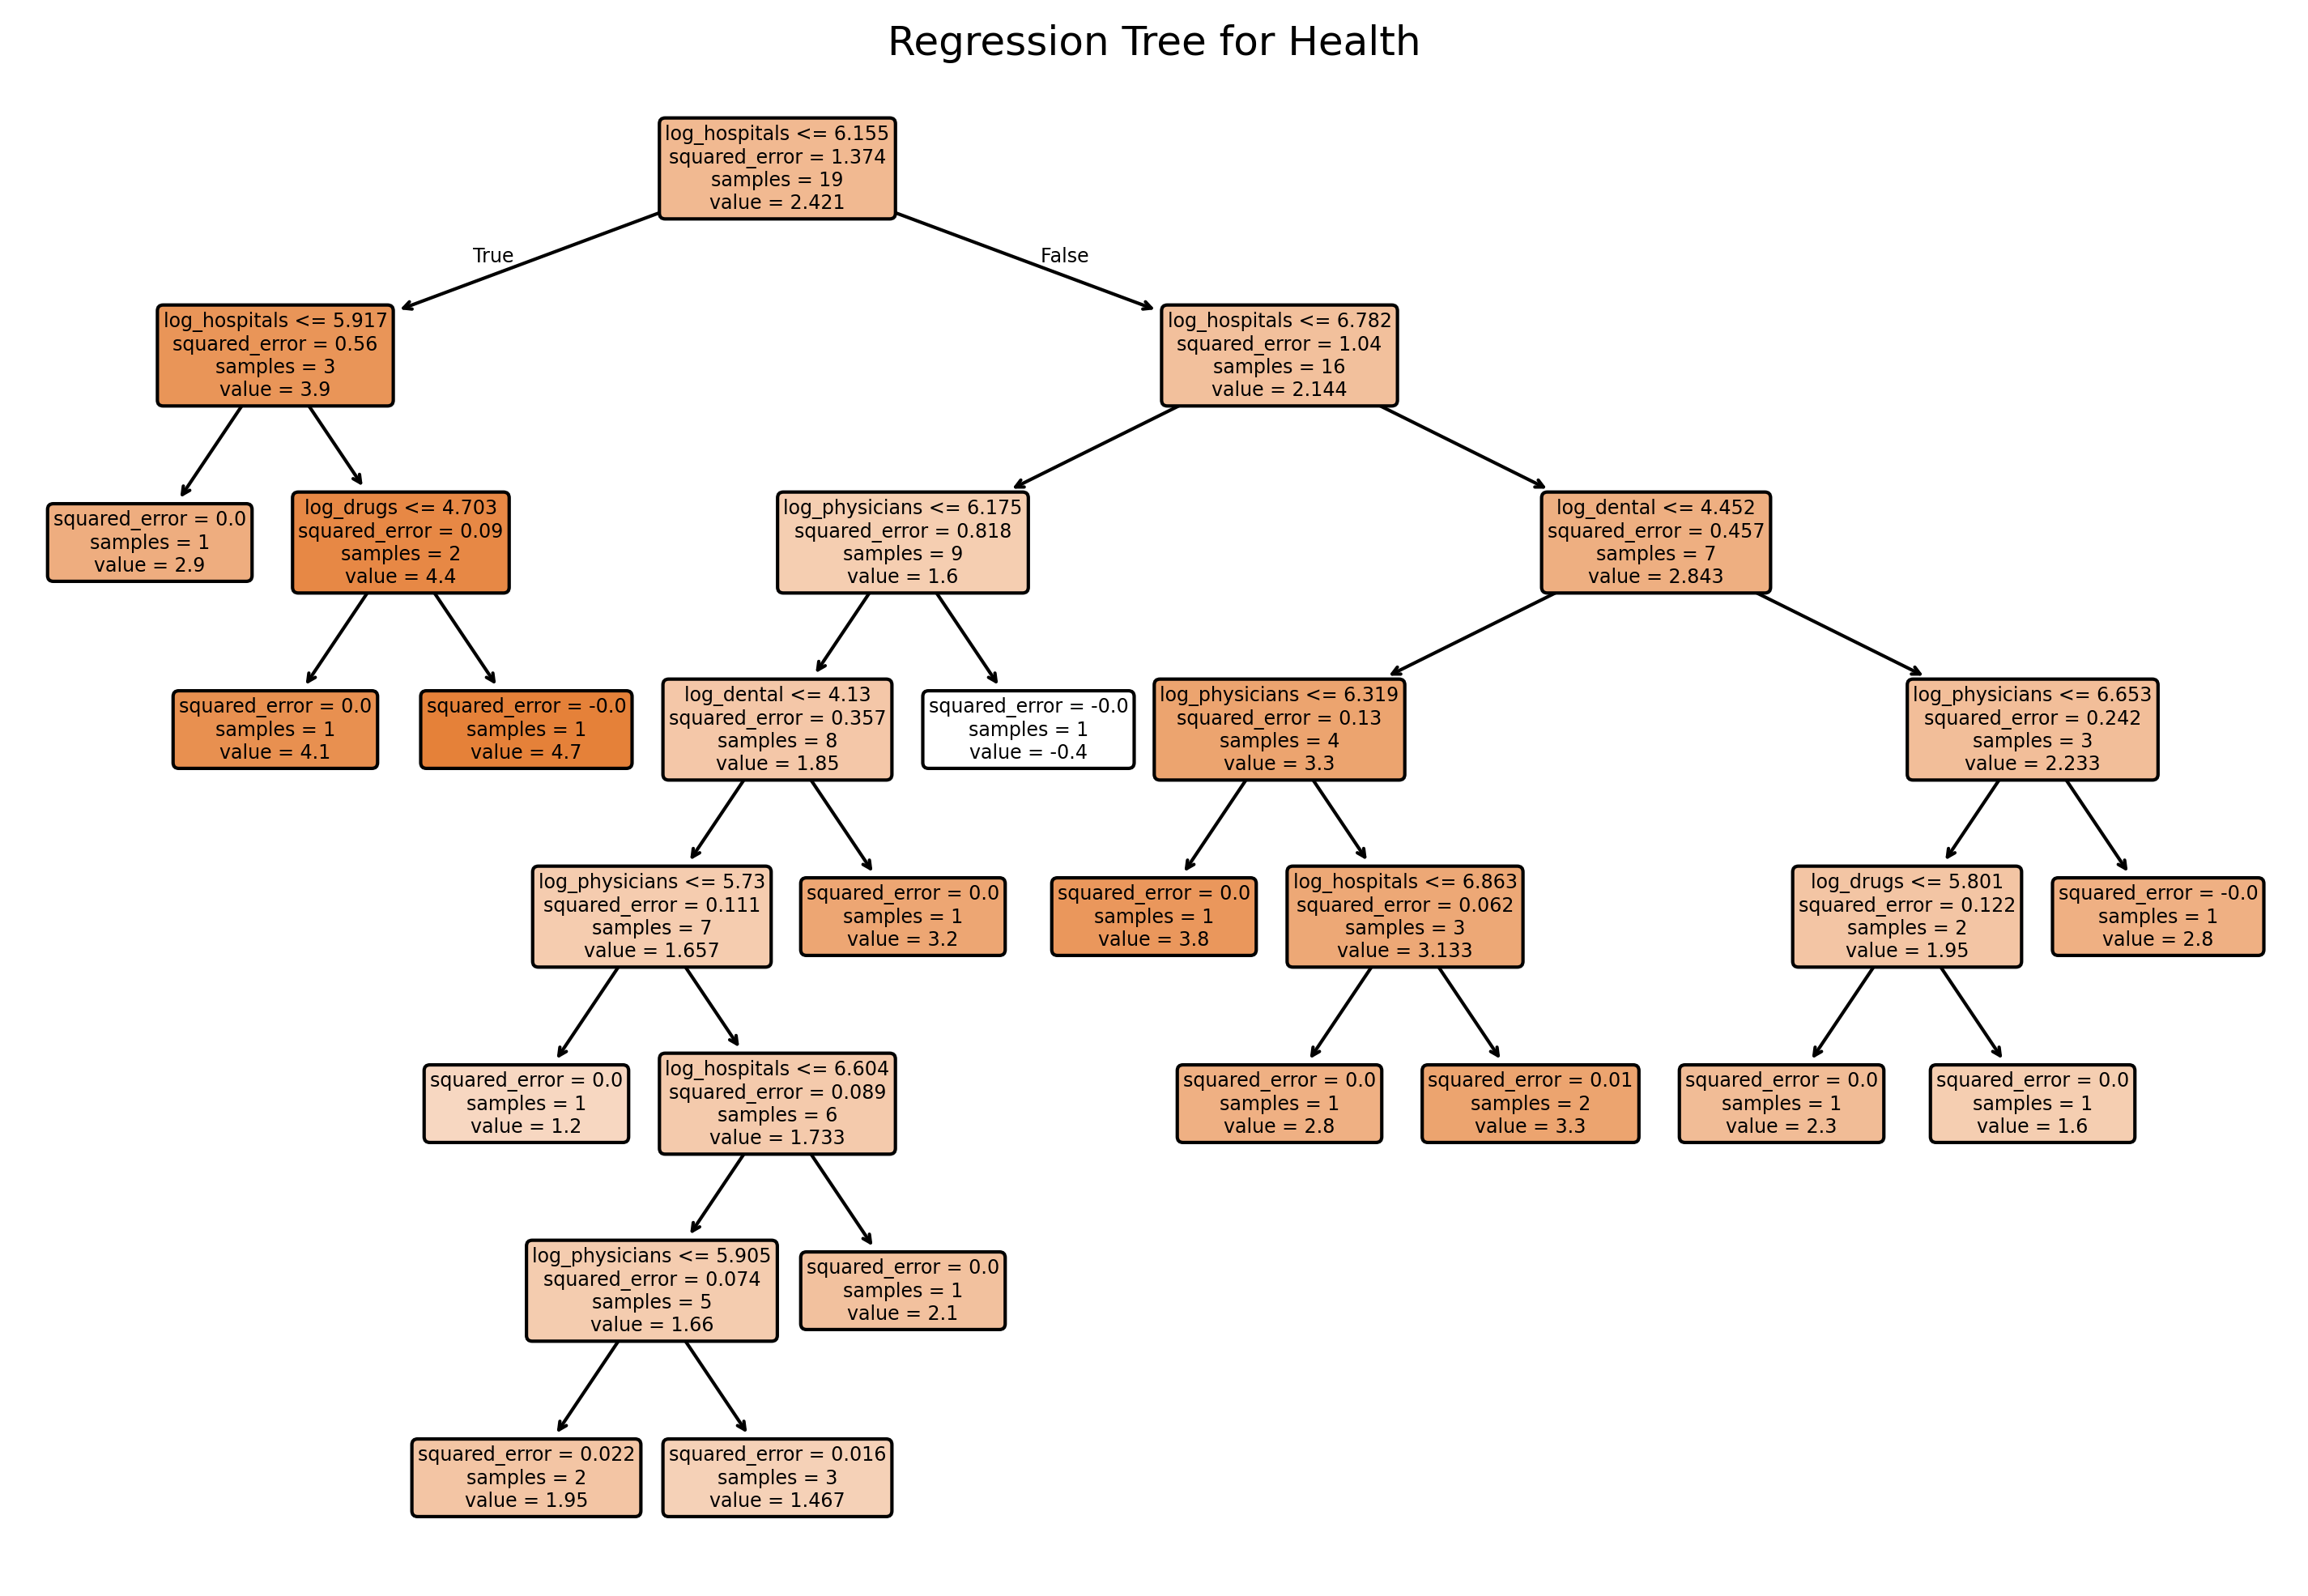

In [ ]:
# In scikit-learn, we can use min_impurity_decrease=0.005 for a similar effect.
tree_model = DecisionTreeRegressor(min_impurity_decrease=0.005, random_state=42)
# Fit the model using all predictors (all columns except 'medv')
tree_model.fit(X_train, y_train)


# Predict on training and test sets
y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

# Calculate MSE
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training MSE: {mse_train:.3f}")
print(f"Test MSE: {mse_test:.3f}")

# Plot the initial regression tree
plt.figure(figsize=(12, 8), dpi = 300)
plot_tree(tree_model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Regression Tree for Health")
plt.show()

The regression tree clearly shows that hospital costs are the strongest predictor of overall health-related outcomes, but physician, dental, and drug costs also interact meaningfully. This tool helps uncover not just which variables matter most, but how they work together to influence healthcare metrics.
Top Split (Most Important Variable):
The first and most influential variable in predicting the target is log_hospitals, with a split at ≤ 6.155. This suggests that hospital-related costs or usage are the strongest factor driving differences in the outcome.


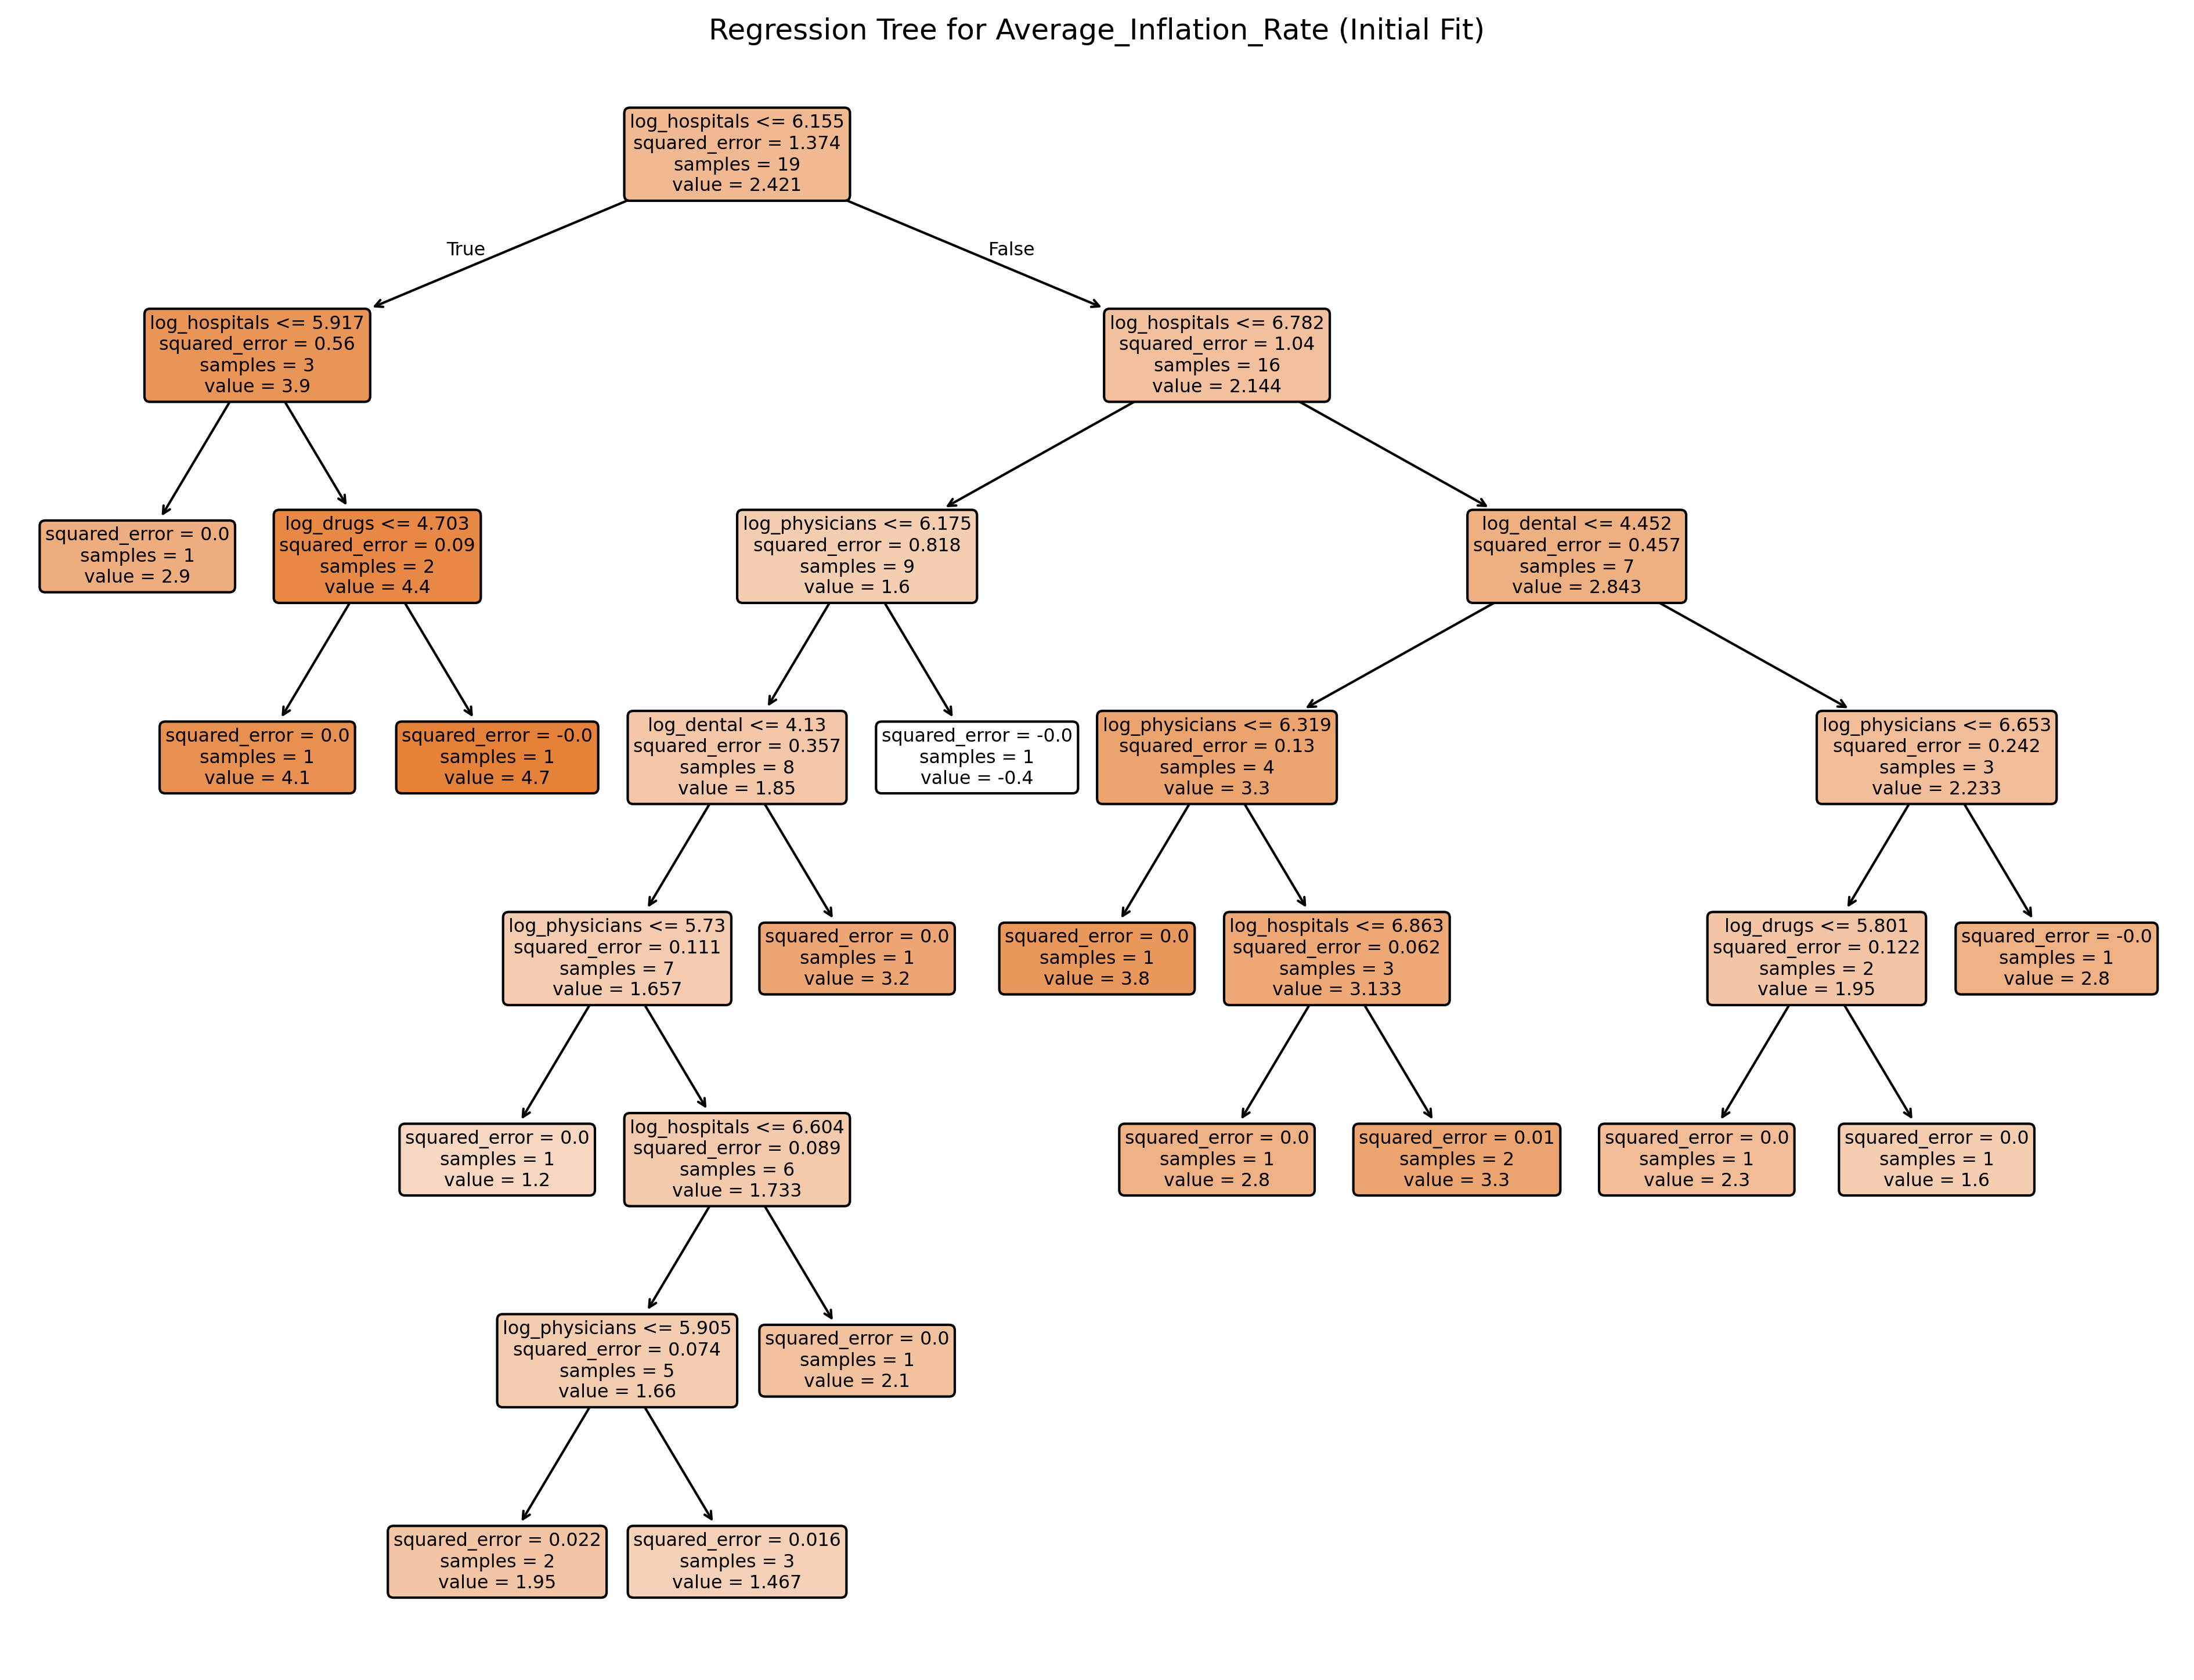

In [ ]:
# Prepping training and test data
dtrain_pd = dtrain.toPandas()
dtest_pd = dtest.toPandas()

X_train = dtrain_pd[conti_cols]
X_test = dtest_pd[conti_cols]
y_train = dtrain_pd['Average_Inflation_Rate']
y_test = dtest_pd['Average_Inflation_Rate']


# Without max_depth=3
tree_model = DecisionTreeRegressor(min_impurity_decrease=0.005, random_state=42)
tree_model.fit(X_train, y_train)

# Plot the initial regression tree
plt.figure(figsize=(16, 12), dpi=300)
plot_tree(tree_model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Regression Tree for Average_Inflation_Rate (Initial Fit)")
plt.show()

RandomForestRegressor(max_features=13, n_estimators=500, oob_score=True,
                      random_state=42)
Train MSE: 0.284798288421054
Test MSE: 3.4183904159999927
Early-year data points generally lie close to the red prediction line, suggesting the model fits reasonably well at the start of the timeline.


However, in later years (particularly around Year = 8), the actual cost is well below the predicted value, indicating prediction error or model overestimation.


This suggests the model might be overfitting to earlier data or that dental costs didn’t increase as rapidly as the model expected in the more recent years.


In [ ]:
# Obtain the cost-complexity pruning path from the initial tree
path = tree_model.cost_complexity_pruning_path(X_train, y_train)  # Get candidate ccp_alpha values and corresponding impurities
ccp_alphas = path.ccp_alphas  # Candidate pruning parameters (alpha values)
impurities = path.impurities  # Impurity values at each candidate alpha

# Exclude the maximum alpha value to avoid the trivial tree (a tree with only the root)
ccp_alphas = ccp_alphas[:-1]  # Remove the last alpha value which would prune the tree to a single node

# Set up 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)  # Initialize 10-fold CV with shuffling and fixed random state
cv_scores = []  # List to store mean cross-validated scores (negative MSE)
leaf_nodes = []  # List to record the number of leaves for each pruned tree

# Loop over each candidate alpha value to evaluate its performance
for ccp_alpha in ccp_alphas:
    # Create a DecisionTreeRegressor with the current ccp_alpha and other specified parameters
    clf = DecisionTreeRegressor(random_state=42,
                                ccp_alpha=ccp_alpha,
                                min_impurity_decrease=0.005)

    # Perform 10-fold cross-validation and compute negative mean squared error (MSE)
    scores = cross_val_score(clf, X_train, y_train,
                             cv=kf, scoring="neg_mean_squared_error")
    cv_scores.append(np.mean(scores))  # Append the mean CV score for the current alpha

    # Fit the tree on the training data to record additional metrics
    clf.fit(X_train, y_train)
    leaf_nodes.append(clf.get_n_leaves())  # Record the number of leaf nodes in the tree

# Select the best alpha based on the highest (least negative) mean CV score
best_alpha = ccp_alphas[np.argmax(cv_scores)]  # Identify the alpha with the best CV performance
print("Best alpha:", best_alpha)  # Print the best alpha value

# Train the final pruned tree using the best alpha found
final_tree = DecisionTreeRegressor(random_state=42,
                                   ccp_alpha=best_alpha,
                                   min_impurity_decrease=0.005)
final_tree.fit(X_train, y_train)  # Fit the final model on the training data
path = tree_model.cost_complexity_pruning_path(X_train, y_train)  # Get candidate ccp_alpha values and corresponding impurities
ccp_alphas = path.ccp_alphas  # Candidate pruning parameters (alpha values)
impurities = path.impurities  # Impurity values at each candidate alpha

# Exclude the maximum alpha value to avoid the trivial tree (a tree with only the root)
  # Remove the last alpha value which would prune the tree to a single node
ccp_alphas = ccp_alphas[:-1]

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []  # mean CV scores (negative MSE)
leaf_nodes = []
sse = []

# Loop over each candidate alpha value to evaluate its performance
for ccp_alpha in ccp_alphas:
    # Create a DecisionTreeRegressor with the current ccp_alpha and other specified parameters
    clf = DecisionTreeRegressor(random_state=42,
                                ccp_alpha=ccp_alpha,
                                min_impurity_decrease=0.005)

    # Perform 10-fold cross-validation and compute negative mean squared error (MSE)
    scores = cross_val_score(clf, X_train, y_train,
                             cv=kf, scoring="neg_mean_squared_error")
    cv_scores.append(np.mean(scores))  # Append the mean CV score for the current alpha

    # Fit the tree on the training data to record additional metrics
    clf.fit(X_train, y_train)
    leaf_nodes.append(clf.get_n_leaves())  # Record the number of leaf nodes in the tree

    # Compute SSE (sum of squared errors) on the training set
    preds = clf.predict(X_train)  # Predict target values on training data
    sse.append(np.sum((y_train - preds) ** 2))  # Calculate and record SSE for training set

# Select the best alpha based on the highest (least negative) mean CV score
best_alpha = ccp_alphas[np.argmax(cv_scores)]  # Identify the alpha with the best CV performance
print("Best alpha:", best_alpha)  # Print the best alpha value

# Train the final pruned tree using the best alpha found
final_tree = DecisionTreeRegressor(random_state=42,
                                   ccp_alpha=best_alpha,
                                   min_impurity_decrease=0.005)
final_tree.fit(X_train, y_train)  # Fit the final model on the training data

Best alpha: 0.23684210526315772
Best alpha: 0.23684210526315772


DecisionTreeRegressor(ccp_alpha=np.float64(0.23684210526315772),
                      min_impurity_decrease=0.005, random_state=42)

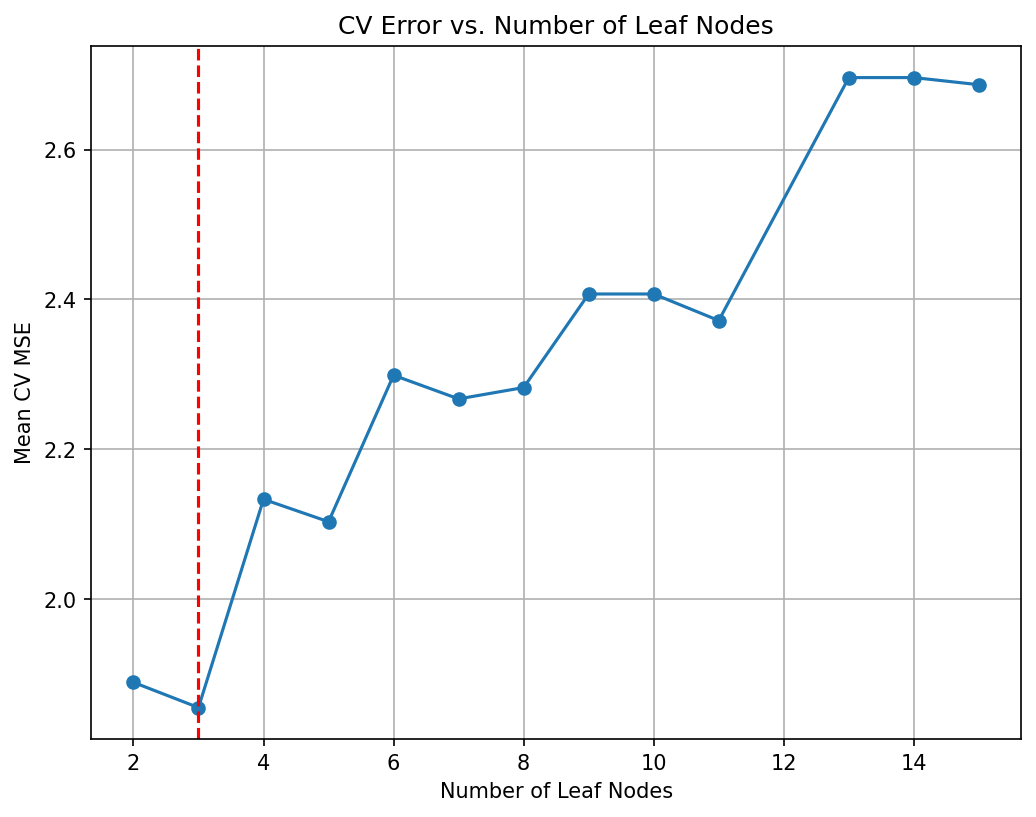

In [ ]:
# Plot the average cross-validated MSE against the number of leaf nodes
negative_cv_scores = -np.array(cv_scores)

plt.figure(figsize=(8, 6), dpi=150)
plt.plot(leaf_nodes, negative_cv_scores, marker='o', linestyle='-')
plt.axvline(x=final_tree.get_n_leaves(), color='red', linestyle='--', label='Leaf Nodes = 21')  # Add vertical line at 21 leaf nodes
plt.xlabel("Number of Leaf Nodes")
plt.ylabel("Mean CV MSE")
plt.title("CV Error vs. Number of Leaf Nodes")
plt.grid(True)
plt.show()

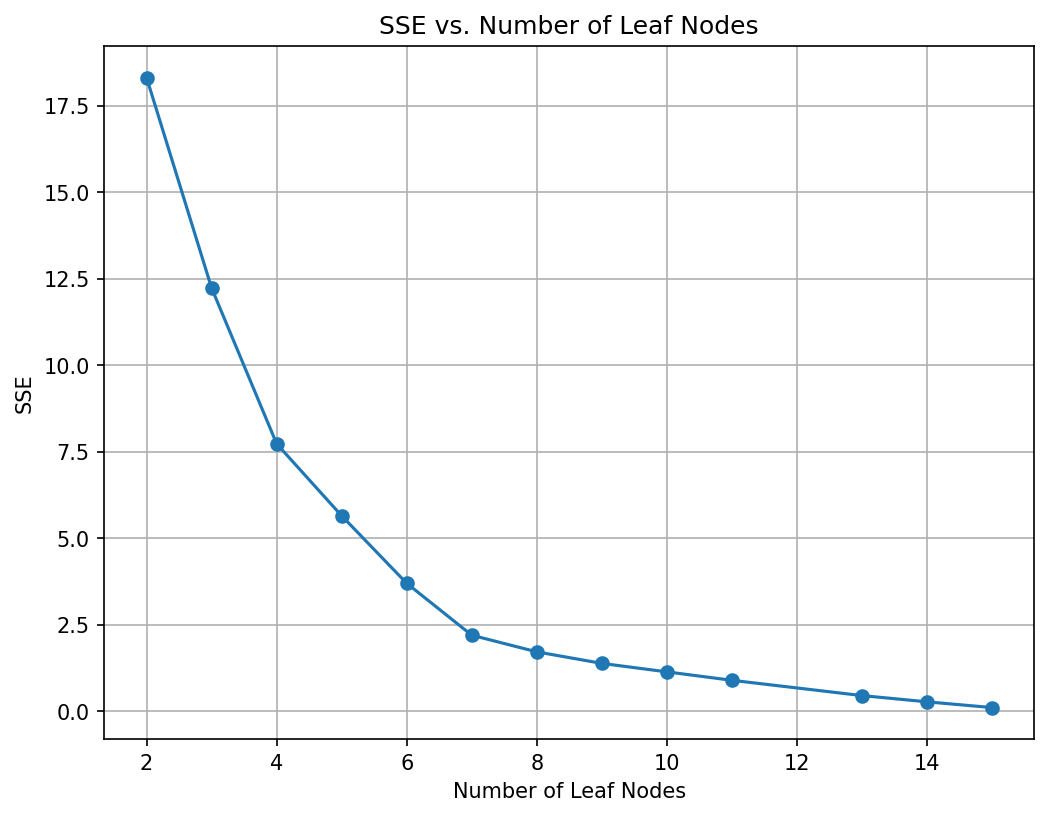

In [ ]:
# Plot the SSE on the training against the number of leaf nodes
plt.figure(figsize=(8, 6), dpi=150)
plt.plot(leaf_nodes, sse, marker='o', linestyle='-')
plt.xlabel("Number of Leaf Nodes")
plt.ylabel("SSE")
plt.title("SSE vs. Number of Leaf Nodes")
plt.grid(True)
plt.show()


Random Forest

Random Forest Model:
RandomForestRegressor(max_features=13, n_estimators=500, oob_score=True,
                      random_state=42)
Train MSE: 0.284798288421054
Test MSE: 3.4183904159999927


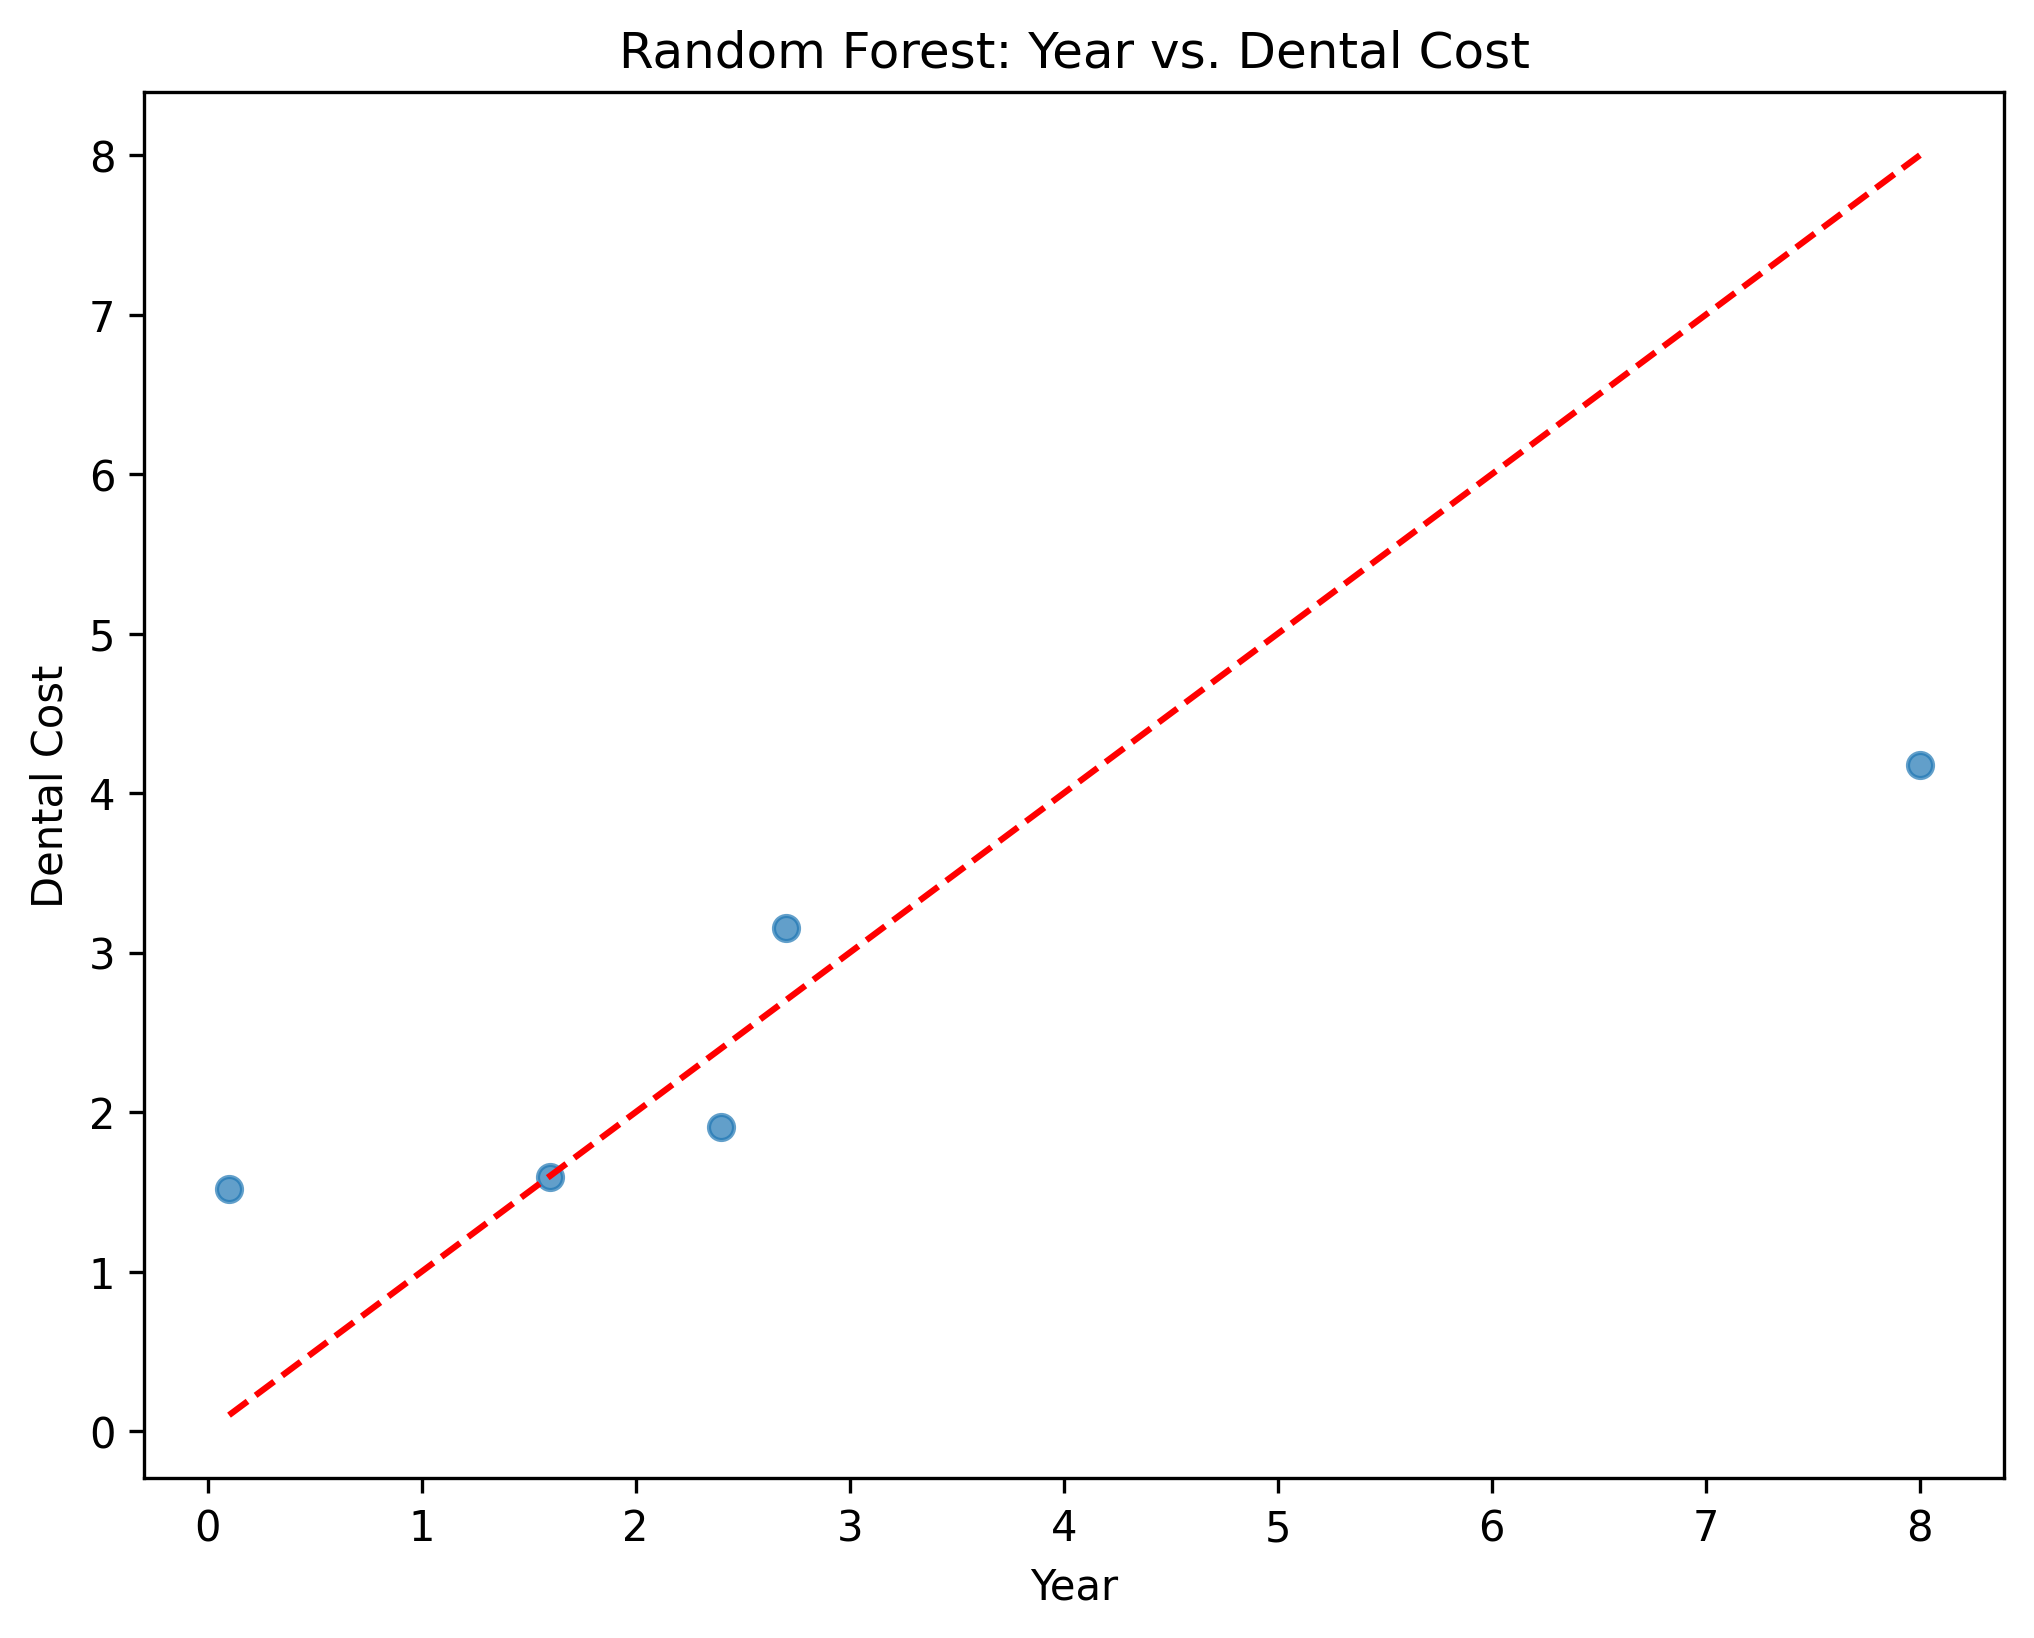

In [ ]:
# Build the Random Forest model
# max_features=13 means that at each split the algorithm randomly considers 13 predictors.
rf = RandomForestRegressor(max_features=13,  # Use 13 features at each split
                           n_estimators=500,  # Number of trees in the forest
                           random_state=42,
                           oob_score=True)    # Use out-of-bag samples to estimate error
rf.fit(X_train, y_train)


# Print the model details
print("Random Forest Model:")
print(rf)

# Output the model details (feature importances, OOB score, etc.)
#print("Dental:", rf.dental_score_)  # A rough estimate of generalization error


# Generate predictions on training and testing sets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Calculate Mean Squared Errors (MSE) for both sets
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

#Plot predicted vs. observed values for test data
plt.figure(figsize=(8,6), dpi=300)
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Year")
plt.ylabel("Dental Cost")
plt.title("Random Forest: Year vs. Dental Cost")
plt.show()

###**Homework 5 Parts**

```

```



Density Plots

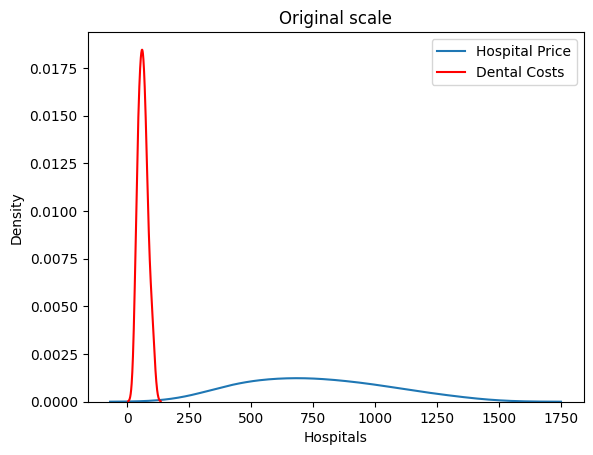

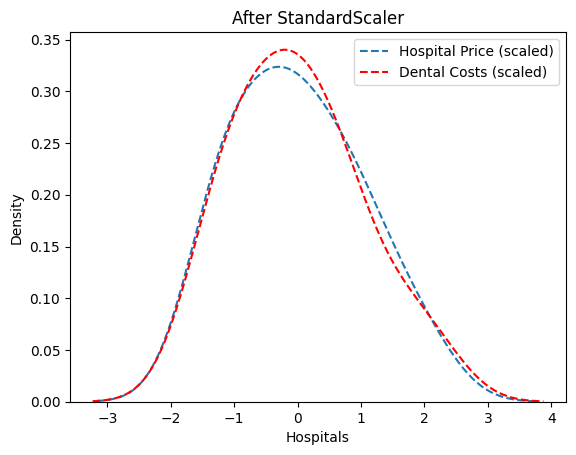

In [ ]:
vars_to_use = ['Year','Average_Inflation_Rate','Hospitals','Physicians_and_Clinics','Dental','Non-Durable_Medical_Products',
               'Other_Professional_Services','Retail_Prescription_Drugs','Home_Health','Nursing_Care','Other_Health_and_Residential',
               'Health_Consumption','Personal_Health_Care','Durable_Medical_Equipment','State_and_Local_Administration',
               'Total_Administration','Federal_Administration','Net_Cost_of_Health_Insurance','Total_National_Health_Expenditures']
scaler = StandardScaler()

# computes those means and standard deviations on your selected columns
  # and returns a NumPy array (`pmatrix`)
  # where each column now has mean 0 and variance 1.
pmatrix = scaler.fit_transform(health[vars_to_use])

pcenter, pscale = scaler.mean_, scaler.scale_

fig, ax = plt.subplots()
sns.kdeplot(data=health, x="Hospitals", ax=ax, label="Hospital Price")
sns.kdeplot(data=health, x="Dental", ax=ax, color="red", label="Dental Costs")
ax.set_title("Original scale"); ax.legend(); plt.show()

scaled_df = pd.DataFrame(pmatrix, columns=vars_to_use)
fig, ax = plt.subplots()
sns.kdeplot(data=scaled_df, x="Hospitals", ax=ax, linestyle="--", label="Hospital Price (scaled)")
sns.kdeplot(data=scaled_df, x="Dental", ax=ax, color="red", linestyle="--",
            label="Dental Costs (scaled)")
ax.set_title("After StandardScaler"); ax.legend(); plt.show()

Hierarchal Clustering - Dendrogram

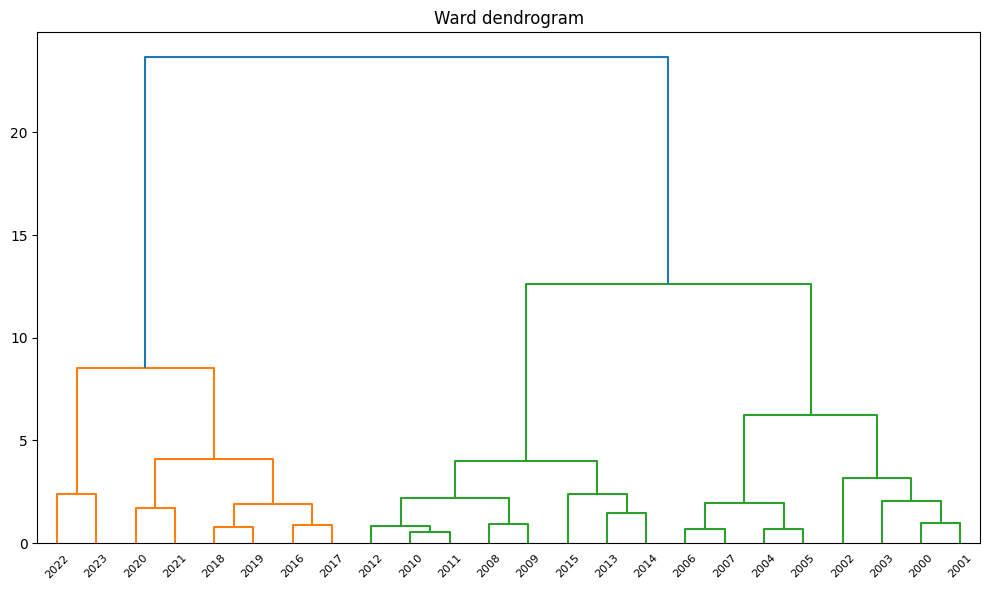

In [ ]:
link = linkage(pmatrix, method="ward")
plt.figure(figsize=(10, 6))
dendrogram(link, labels=health['Year'].values, leaf_font_size=8)
plt.title("Ward dendrogram"); plt.tight_layout(); plt.show()

This dendrogram shows the similar healthcare spending patterns across every year from 2000 to 2023. The higher a horizontal connecting line is in the graph, the less similar the spending patterns between two years are. The colors represent similar clusters, which can be interpreted as “eras” of healthcare spending.
Between 2016 and 2023, there were significant shifts in US inflation, with a notable increase in the late 2020s. In the early part of this period (2016-2019), inflation was relatively stable and below the Federal Reserve's target of 2%. Then, inflation surged during the pandemic in 2020-2022, reaching its peak in 2022. By 2023, inflation began to cool down, but remained above the pre-pandemic levels.
Between 2016 and 2023, healthcare spending shifted towards faster growth, particularly after the COVID-19 pandemic, and with inflation playing a significant role. While the average annual growth for 2016-19 was 1.4%, it accelerated to 2.5% during 2020-22 and further to 3.0% in 2023, Health Affairs. This increase in spending was largely driven by higher prices for hospital services, physician services, and prescription drugs.



Hierarchal Clustering

In [ ]:
groups_hc = fcluster(link, t=5, criterion="maxclust")      # k = 5

# Convenience: print selected cols by cluster
def print_clusters(df: pd.DataFrame, labels, cols):
    for k, sub in df.assign(cluster=labels).groupby("cluster"):
        print(f"\nCluster {k} ({len(sub)} obs)")
        print(sub[cols].to_string(index=False))

cols_to_print = ['Year', 'Dental', 'Physicians_and_Clinics', 'Hospitals']
print_clusters(health, groups_hc, cols_to_print)


Cluster 1 (2 obs)
 Year  Dental  Physicians_and_Clinics  Hospitals
 2022   95.59                  743.35    1203.19
 2023  104.11                  808.78    1322.83

Cluster 2 (6 obs)
 Year  Dental  Physicians_and_Clinics  Hospitals
 2016   71.65                  541.28     902.19
 2017   74.80                  568.58     937.10
 2018   78.28                  591.87     976.60
 2019   81.38                  620.50    1033.20
 2020   74.94                  629.99    1031.30
 2021   90.40                  687.53    1141.47

Cluster 3 (8 obs)
 Year  Dental  Physicians_and_Clinics  Hospitals
 2008   53.79                  377.30     629.74
 2009   56.27                  395.79     670.91
 2010   59.15                  406.21     698.73
 2011   60.43                  426.46     720.92
 2012   61.45                  443.14     755.51
 2013   62.91                  451.78     775.74
 2014   65.98                  480.03     810.39
 2015   68.15                  511.37     861.89

Cluster 4 (

PCA

In [ ]:
groups_hc_limit = groups_hc[12:24]
health_limit = health.iloc[12:24]

pca = PCA(n_components=19).fit(pmatrix)
proj = pca.transform(pmatrix)[: :2]

proj_df = (
    pd.DataFrame(proj, columns=[f"PC{i+1}" for i in range(19)])
      .assign(cluster=groups_hc_limit.astype(int),
              country=health_limit['Year'].values)
)

proj_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,cluster,country
0,-6.667066,0.063123,-0.397139,-0.445762,-0.025937,-0.250773,-0.096611,-0.044344,-0.056657,-0.021588,...,0.011221,-0.035710,-0.011098,0.024847,0.004217,0.000002,-6.717989e-06,1.474524e-06,3,2012
1,-5.572609,2.940437,0.941744,0.075383,-0.032793,-0.024546,0.063208,0.083835,0.000734,0.020595,...,0.023135,0.007300,0.010861,0.006530,0.000973,-0.000002,-5.102796e-07,-2.609147e-06,3,2013
2,-4.168596,-0.961401,-0.355936,-0.314048,0.099399,-0.017623,0.007812,-0.042803,0.095647,-0.011545,...,-0.028177,0.030325,-0.008806,-0.003858,-0.008896,-0.000007,1.306556e-05,-2.088636e-06,3,2014
3,-2.961976,-0.310628,0.128367,-0.083342,0.183194,0.308602,0.048456,0.034723,-0.040366,0.020314,...,-0.026718,-0.024944,-0.014818,-0.007998,0.013159,-0.000009,-1.033323e-06,-2.218770e-06,3,2015
4,-1.835688,-1.062667,0.278598,0.035039,0.037106,0.158208,-0.004390,0.032582,-0.030992,-0.007437,...,0.032705,-0.013211,0.020047,-0.008043,-0.005828,-0.000010,-4.420917e-06,-1.360207e-06,2,2016
5,-0.875711,-0.949083,0.547280,0.310442,-0.026586,-0.084445,0.009296,-0.063345,0.022743,-0.018364,...,-0.016052,0.005911,-0.007343,0.013824,-0.004533,0.000028,-3.112570e-06,-2.354939e-06,2,2017
6,-0.059103,-0.704931,0.878051,0.369636,-0.044133,-0.181342,-0.113867,0.066837,0.040370,-0.003145,...,-0.046054,-0.014591,-0.007132,-0.012328,-0.005301,-0.000022,-1.086254e-05,-1.559381e-06,2,2018
7,0.835132,-0.337731,-0.671212,0.220572,-0.084806,0.185868,0.046072,-0.022426,-0.009791,0.018758,...,0.042166,0.023497,-0.038502,0.014067,-0.008989,0.000010,-9.693963e-06,-1.225554e-06,2,2019
8,1.942238,1.169287,-0.588189,0.241527,-0.179613,-0.078340,0.113922,0.037328,0.006225,-0.029633,...,-0.027731,0.010395,0.004272,0.030328,-0.000443,-0.000015,4.609556e-06,9.986845e-07,2,2020
9,3.265397,0.981091,-0.831870,0.093340,0.048835,0.025586,-0.003694,-0.075464,0.131530,0.024466,...,0.022078,-0.044660,-0.012626,-0.008037,0.006153,-0.000029,1.228865e-06,8.588205e-07,2,2021


In [ ]:
# Compute PCA loading vectors
loadings_nba = pd.DataFrame(
    pca.components_.T,  # Transpose of PCA components to get loadings
    index=vars_to_use,  # Numeric columns used in PCA
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]  # Name PCs as PC1, PC2, ...
)

# Print the first 3 loading vectors (for PC1, PC2, PC3)
print(loadings_nba.iloc[:, :3].round(2))

                                     PC1   PC2   PC3
Year                                0.24  0.02 -0.16
Average_Inflation_Rate             -0.06  0.92  0.37
Hospitals                           0.24  0.03 -0.03
Physicians_and_Clinics              0.24  0.05 -0.02
Dental                              0.24  0.02  0.03
Non-Durable_Medical_Products        0.17 -0.36  0.87
Other_Professional_Services         0.24  0.05  0.08
Retail_Prescription_Drugs           0.24 -0.02 -0.03
Home_Health                         0.24  0.01 -0.04
Nursing_Care                        0.24 -0.06 -0.03
Other_Health_and_Residential        0.24  0.06 -0.02
Health_Consumption                  0.24  0.03 -0.03
Personal_Health_Care                0.24  0.02 -0.02
Durable_Medical_Equipment           0.24  0.02  0.11
State_and_Local_Administration      0.24  0.00  0.03
Total_Administration                0.24  0.07 -0.12
Federal_Administration              0.24  0.07 -0.14
Net_Cost_of_Health_Insurance        0.24  0.07

Scree Plot

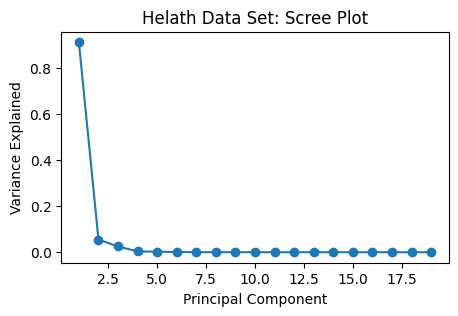

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, pca.n_components_ + 1), pca.explained_variance_ratio_, "o-")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Helath Data Set: Scree Plot")
plt.show()

Significance of the project: The findings from the data analysis above reveal clear, actionable insights with significant implications for both public policy and private-sector decision-making. The most important takeaway is that healthcare costs—especially hospital bills and prescription drug prices—have risen steadily and dramatically over time, often outpacing inflation. At the same time, categories like home health services and non-durable medical products have shown unusual or even inverse relationships with inflation, suggesting that healthcare is not uniformly affected by economic trends.


Relevance and Impact: 1. Public Policy & Healthcare Reform
These findings can help lawmakers and health economists target the sources of rising healthcare costs more effectively. For instance:
The sharp rise in hospital and drug costs could justify price regulation, transparency laws, or increased support for generics and preventative care.


The weak or negative correlation between inflation and costs in other healthcare areas suggests that some services (like home health) may be more resilient or efficiently managed. Policymakers could explore expanding support for these cost-effective care models.
2. Business and Healthcare Providers
For healthcare systems and pharmaceutical companies, this analysis:
Highlights the need to balance innovation with affordability.


Encourages data-driven pricing strategies that consider inflation-adjusted consumer and payer behavior.


Could drive investment toward value-based care models that emphasize outcome over volume.




Broader Themes: These findings tie into larger conversations around:
Healthcare affordability and accessibility in the U.S.


The growing burden of medical debt on individuals.


The role of inflation versus institutional pricing in cost growth.


Equity in care delivery, particularly in regions or populations disproportionately affected by rising prices.




Why It Matters: This analysis helps cut through general assumptions—like “inflation always makes everything more expensive”—to show that in healthcare, pricing behavior varies by sector, and those variations matter deeply to real people. By identifying exactly where costs are rising the fastest (and where they’re not), we can better inform policy, optimize spending, and ultimately work toward a more sustainable, equitable healthcare system.
